## EuroSAT Land Use and Land Cover Classification using Machine Learning and Deep Learning

| | |
|---|---|
| **Group Members** | Student 1, Student 2, Student 3 |
| **Submission Date** | YYYY-MM-DD |
| **Course** | [Course Name] |


In [1]:
# Standard library
import os, glob, warnings
from pathlib import Path

# Scientific stack
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from PIL import Image

# Machine learning
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, roc_curve, auc, confusion_matrix,
    ConfusionMatrixDisplay, classification_report, roc_auc_score,
)
from sklearn.preprocessing import label_binarize

# Deep learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications import EfficientNetB0

# Reproducibility and config
warnings.filterwarnings('ignore')
np.random.seed(42)
tf.random.set_seed(42)
os.makedirs('eurosat_files', exist_ok=True)

print(f'TensorFlow : {tf.__version__}')
print(f'NumPy      : {np.__version__}')
print(f'GPU        : {tf.config.list_physical_devices("GPU")}')


TensorFlow : 2.20.0
NumPy      : 2.1.3
GPU        : []


## 1. Data Loading, Processing, and Exploration

### 1.1 Data Preparation

Visit [the EuroSAT data description page](https://github.com/phelber/eurosat) and download the data. Perform basic exploratory data analysis, assessing the class distribution across the dataset and plotting one image from each class in a 2x5 grid.

Flatten the images into a 2D data matrix (n x p, where n is the number of samples and p is the number of pixels in each image). Load these and the labels into numpy arrays. Split the data into training (60%) and testing (40%) datasets, stratified on class labels (so that there is an equal percentage of each class type in each of the training and testing sets).

Lastly, create a grayscale version of this dataset. You will use this for the traditional machine learning models and the first couple of deep learning models.


In [2]:
# Ten land-cover classes (directory names match these strings)
CLASS_NAMES = [
    "AnnualCrop",            # 0
    "Forest",                # 1
    "HerbaceousVegetation",  # 2
    "Highway",               # 3
    "Industrial",            # 4
    "Pasture",               # 5
    "PermanentCrop",         # 6
    "Residential",           # 7
    "River",                 # 8
    "SeaLake",               # 9
]
NUM_CLASSES = len(CLASS_NAMES)

# Dataset root directories (images stored locally in eurosat_files/)
RGB_DIR = "eurosat_files/EuroSAT"
MS_DIR  = "eurosat_files/EuroSATallBands"


In [3]:
def find_class_dir(base_dir: str, class_name: str) -> str | None:
    """Return the class subdirectory path, handling EuroSAT's nested structure."""
    candidates = [
        os.path.join(base_dir, "2750", class_name),
        os.path.join(base_dir, class_name),
    ]
    for p in candidates:
        if os.path.exists(p):
            return p
    return None


def load_rgb_dataset(base_dir: str, class_names: list[str]):
    """
    Load all RGB images into a NumPy array.

    Returns
    -------
    X : uint8 ndarray, shape (N, 64, 64, 3)
    y : int32 ndarray, shape (N,)
    """
    images, labels = [], []
    for idx, name in enumerate(class_names):
        cls_dir = find_class_dir(base_dir, name)
        if cls_dir is None:
            print(f"  [WARN] directory not found: {name}")
            continue
        paths = sorted(glob.glob(os.path.join(cls_dir, "*.jpg")))
        for p in paths:
            images.append(np.array(Image.open(p).convert("RGB")))
            labels.append(idx)
        print(f"  {name:25s}: {len(paths):4d} images")
    return np.array(images, dtype=np.uint8), np.array(labels, dtype=np.int32)


print("Loading RGB images …")
X_rgb, y = load_rgb_dataset(RGB_DIR, CLASS_NAMES)
print(f"\nLoaded: {X_rgb.shape}  |  labels: {y.shape}")
print(f"Pixel range: [{X_rgb.min()}, {X_rgb.max()}]")


Loading RGB images …
  AnnualCrop               : 3000 images
  Forest                   : 3000 images
  HerbaceousVegetation     : 3000 images
  Highway                  : 2500 images
  Industrial               : 2500 images
  Pasture                  : 2000 images
  PermanentCrop            : 2500 images
  Residential              : 3000 images
  River                    : 2500 images
  SeaLake                  : 3000 images

Loaded: (27000, 64, 64, 3)  |  labels: (27000,)
Pixel range: [0, 255]


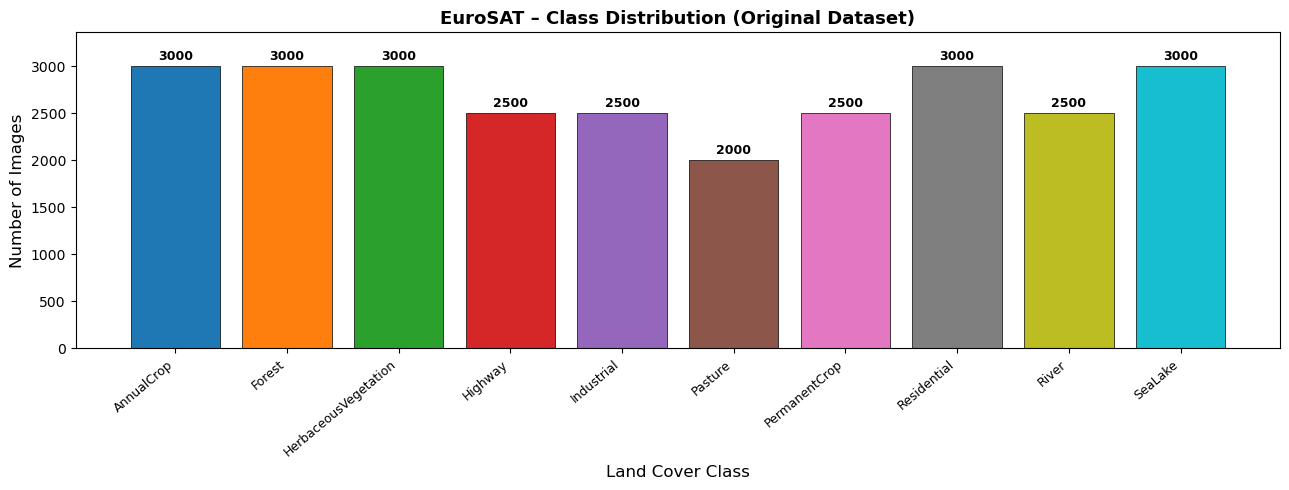

In [4]:
# ── Exploratory data analysis: class distribution ──
CLASS_COLORS = plt.cm.tab10(np.linspace(0, 1, NUM_CLASSES))
unique_cls, counts = np.unique(y, return_counts=True)

fig, ax = plt.subplots(figsize=(13, 5))
bars = ax.bar(
    [CLASS_NAMES[i] for i in unique_cls], counts,
    color=CLASS_COLORS, edgecolor="black", linewidth=0.5,
)
for bar, cnt in zip(bars, counts):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 30,
        str(cnt), ha="center", va="bottom", fontsize=9, fontweight="bold",
    )
ax.set_xlabel("Land Cover Class", fontsize=12)
ax.set_ylabel("Number of Images", fontsize=12)
ax.set_title("EuroSAT – Class Distribution (Original Dataset)", fontsize=13, fontweight="bold")
ax.set_ylim(0, counts.max() * 1.12)
plt.xticks(rotation=40, ha="right", fontsize=9)
plt.tight_layout()
plt.savefig("eurosat_files/class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()


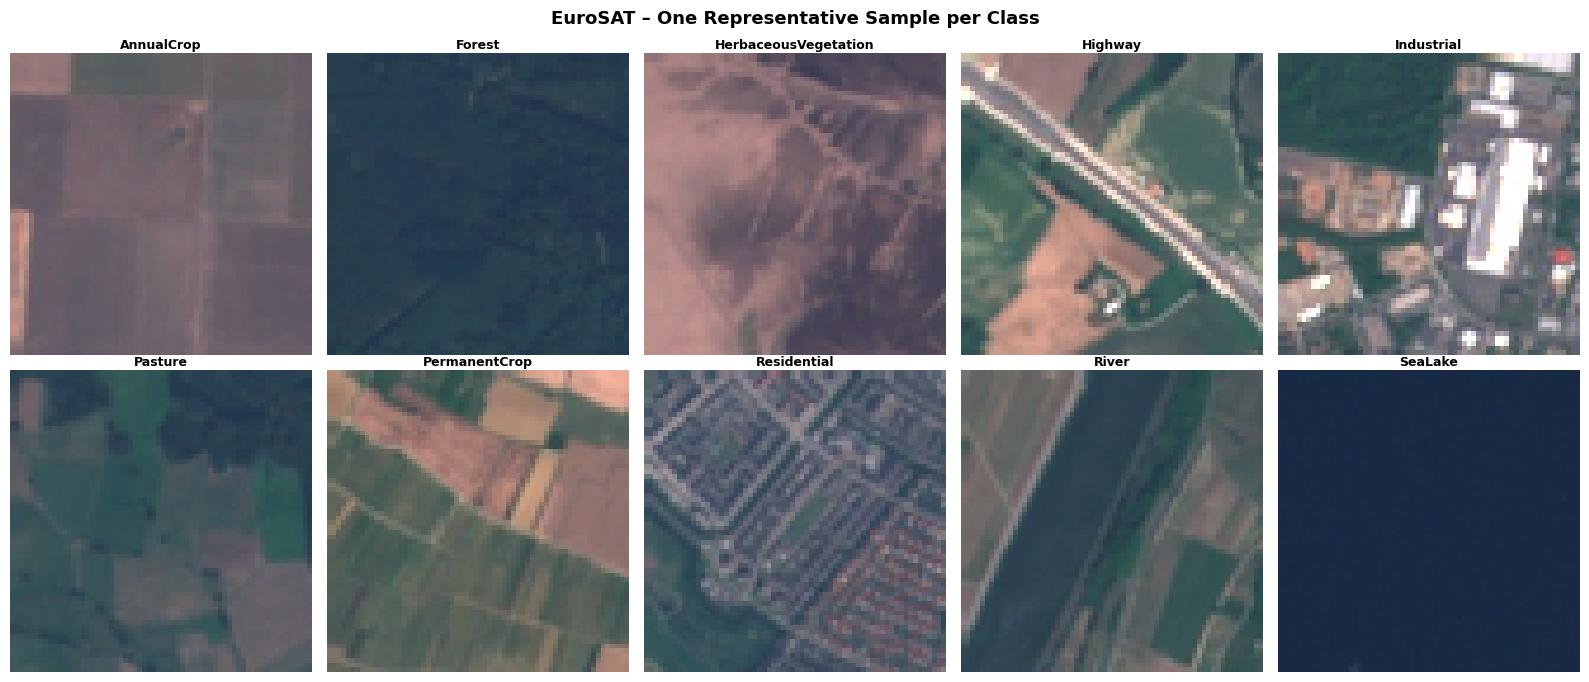

In [5]:
# ── 2×5 grid: one sample image per class ──
fig, axes = plt.subplots(2, 5, figsize=(16, 7))
for idx, (ax, name) in enumerate(zip(axes.flatten(), CLASS_NAMES)):
    sample = X_rgb[np.where(y == idx)[0][0]]
    ax.imshow(sample)
    ax.set_title(name, fontsize=9, fontweight="bold", pad=3)
    ax.axis("off")
    for spine in ax.spines.values():
        spine.set_edgecolor(CLASS_COLORS[idx])
        spine.set_linewidth(2.5)

plt.suptitle("EuroSAT – One Representative Sample per Class", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("eurosat_files/sample_per_class.png", dpi=150, bbox_inches="tight")
plt.show()


### 1.2 Data Augmentation

Before splitting the data into training and testing sets or doing any preprocessing, apply data augmentation to increase the size of the dataset, appending the new samples to the original dataset. Indicate the augmentation approach(es) that you used and the total size of the new dataset. Again, plot three random images and a histogram of the label distribution across the full dataset.

We apply three geometric transforms — horizontal flip, vertical flip, and 90° rotation — to every image before splitting, quadrupling the dataset from 27,000 to 108,000 images.


In [6]:
def augment_dataset(X: np.ndarray, y: np.ndarray):
    """
    Apply three augmentations (hflip, vflip, rot90) to every image.
    Returns only the *new* augmented samples.
    """
    aug_X, aug_y = [], []
    for img, label in zip(X, y):
        aug_X.append(np.fliplr(img))      # horizontal flip
        aug_y.append(label)
        aug_X.append(np.flipud(img))      # vertical flip
        aug_y.append(label)
        aug_X.append(np.rot90(img, k=1))  # 90-degree rotation
        aug_y.append(label)
    return np.array(aug_X, dtype=X.dtype), np.array(aug_y, dtype=y.dtype)


print("Applying data augmentation (horizontal flip, vertical flip, 90° rotation)…")
X_aug, y_aug = augment_dataset(X_rgb, y)

# Combine original + augmented and shuffle
X_full = np.concatenate([X_rgb, X_aug], axis=0)
y_full = np.concatenate([y,     y_aug], axis=0)
perm   = np.random.default_rng(42).permutation(len(X_full))
X_full, y_full = X_full[perm], y_full[perm]

print(f"  Original   : {len(X_rgb):>8,} images")
print(f"  Augmented  : {len(X_aug):>8,} images  (3×)")
print(f"  Combined   : {len(X_full):>8,} images")


Applying data augmentation (horizontal flip, vertical flip, 90° rotation)…
  Original   :   27,000 images
  Augmented  :   81,000 images  (3×)
  Combined   :  108,000 images


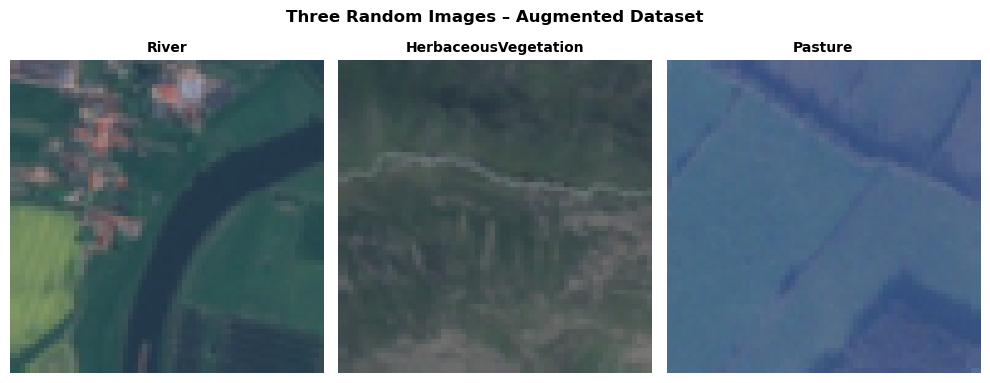

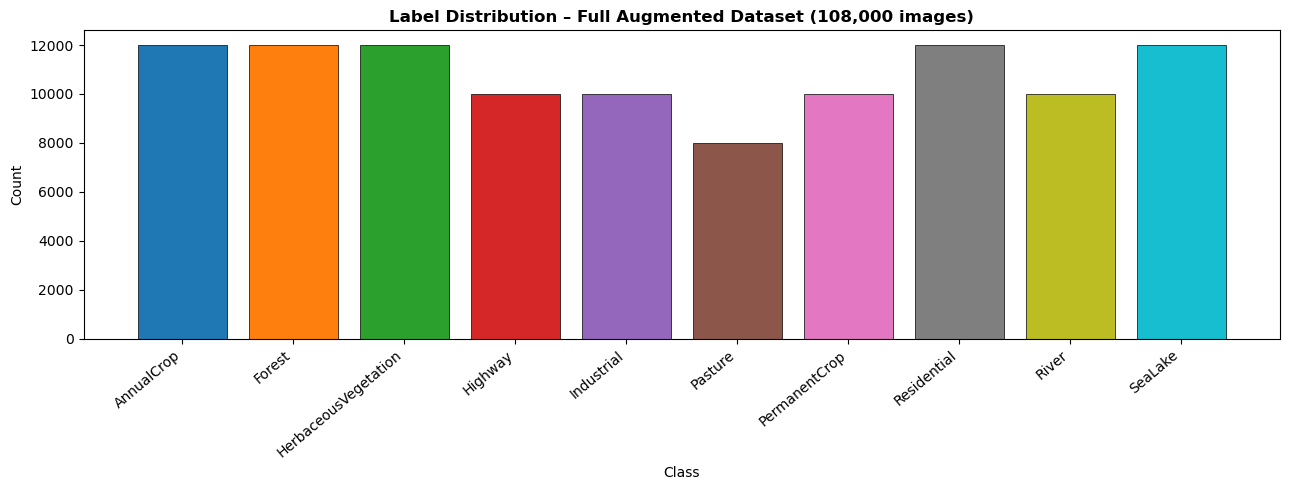

In [7]:
# ── Three random images from the augmented dataset ──
fig, axes = plt.subplots(1, 3, figsize=(10, 4))
for ax, idx in zip(axes, np.random.choice(len(X_full), 3, replace=False)):
    ax.imshow(X_full[idx])
    ax.set_title(CLASS_NAMES[y_full[idx]], fontsize=10, fontweight="bold")
    ax.axis("off")
plt.suptitle("Three Random Images – Augmented Dataset", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("eurosat_files/augmented_samples.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Label histogram after augmentation ──
uni, cnt = np.unique(y_full, return_counts=True)
fig, ax = plt.subplots(figsize=(13, 5))
ax.bar([CLASS_NAMES[i] for i in uni], cnt, color=CLASS_COLORS, edgecolor="black", linewidth=0.5)
ax.set_title("Label Distribution – Full Augmented Dataset (108,000 images)",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Class"); ax.set_ylabel("Count")
plt.xticks(rotation=40, ha="right")
plt.tight_layout()
plt.savefig("eurosat_files/augmented_distribution.png", dpi=150, bbox_inches="tight")
plt.show()


In [8]:
# ── Stratified 60 / 40 train-test split ──
X_train_rgb, X_test_rgb, y_train, y_test = train_test_split(
    X_full, y_full, test_size=0.40, stratify=y_full, random_state=42
)
print(f"Training : {X_train_rgb.shape}  ({len(y_train):,} samples)")
print(f"Testing  : {X_test_rgb.shape}  ({len(y_test):,} samples)")
print("\nPer-class counts – training set:")
for i, name in enumerate(CLASS_NAMES):
    print(f"  {name:25s}: {np.sum(y_train == i):,}")


Training : (64800, 64, 64, 3)  (64,800 samples)
Testing  : (43200, 64, 64, 3)  (43,200 samples)

Per-class counts – training set:
  AnnualCrop               : 7,200
  Forest                   : 7,200
  HerbaceousVegetation     : 7,200
  Highway                  : 6,000
  Industrial               : 6,000
  Pasture                  : 4,800
  PermanentCrop            : 6,000
  Residential              : 7,200
  River                    : 6,000
  SeaLake                  : 7,200


In [9]:
def rgb_to_gray(X: np.ndarray) -> np.ndarray:
    """Convert uint8 RGB to float32 grayscale via ITU-R BT.601 coefficients."""
    return (0.2989 * X[..., 0] + 0.5870 * X[..., 1] + 0.1140 * X[..., 2]).astype(np.float32)


# Grayscale normalised to [0, 1]
X_train_gray = rgb_to_gray(X_train_rgb) / 255.0   # shape (n, 64, 64)
X_test_gray  = rgb_to_gray(X_test_rgb)  / 255.0

# Flattened grayscale for traditional ML:  (n, 4096)
X_train_flat = X_train_gray.reshape(len(X_train_gray), -1)
X_test_flat  = X_test_gray.reshape(len(X_test_gray),  -1)

# Normalised RGB for CNN / transfer learning:  (n, 64, 64, 3)
X_train_rgb_n = X_train_rgb.astype(np.float32) / 255.0
X_test_rgb_n  = X_test_rgb.astype(np.float32)  / 255.0

print("Preprocessed arrays:")
print(f"  X_train_flat     : {X_train_flat.shape}   (64×64 = 4096 features)")
print(f"  X_train_gray     : {X_train_gray.shape}   (for DL grayscale)")
print(f"  X_train_rgb_n    : {X_train_rgb_n.shape}   (for CNN / transfer)")


Preprocessed arrays:
  X_train_flat     : (64800, 4096)   (64×64 = 4096 features)
  X_train_gray     : (64800, 64, 64)   (for DL grayscale)
  X_train_rgb_n    : (64800, 64, 64, 3)   (for CNN / transfer)


---

## 2. Traditional Machine Learning

For this section, focus on three categories: "Forest (F)", "Residential (R)", and "Industrial (I)". Make sure to subset the grayscale dataset, selecting only these three classes.


In [10]:
# Map three target classes to compact indices 0, 1, 2
FOREST_IDX      = CLASS_NAMES.index("Forest")       # 1
INDUSTRIAL_IDX  = CLASS_NAMES.index("Industrial")   # 4
RESIDENTIAL_IDX = CLASS_NAMES.index("Residential")  # 7

ML_IDX_ORIG = [FOREST_IDX, INDUSTRIAL_IDX, RESIDENTIAL_IDX]
ML_NAMES    = ["Forest", "Industrial", "Residential"]   # 0, 1, 2
LABEL_MAP   = {FOREST_IDX: 0, INDUSTRIAL_IDX: 1, RESIDENTIAL_IDX: 2}


def subset_and_remap(X, y, original_indices, label_map):
    """Filter dataset to selected original class indices and remap to 0..k-1."""
    mask  = np.isin(y, original_indices)
    y_new = np.array([label_map[lbl] for lbl in y[mask]])
    return X[mask], y_new


X_train_ml, y_train_ml = subset_and_remap(X_train_flat, y_train, ML_IDX_ORIG, LABEL_MAP)
X_test_ml,  y_test_ml  = subset_and_remap(X_test_flat,  y_test,  ML_IDX_ORIG, LABEL_MAP)

print(f"ML training set : {X_train_ml.shape}")
print(f"ML testing set  : {X_test_ml.shape}")
print(f"Class distribution (train): { {n: int(np.sum(y_train_ml == i)) for i, n in enumerate(ML_NAMES)} }")


ML training set : (20400, 4096)
ML testing set  : (13600, 4096)
Class distribution (train): {'Forest': 7200, 'Industrial': 6000, 'Residential': 7200}


### 2.1 Binary Support Vector Machine

Implement three binary SVM classifiers (use a linear kernel and default parameters) to classify [F vs R], [F vs I], and [R vs I]. Report the accuracy of each classifier, plot their ROC curves, calculate the AUCs, and show one image that is mis-classified by each classifier, including both the predicted label and the ground truth.


In [11]:
# Three binary pairs using remapped labels (F=0, I=1, R=2)
BINARY_PAIRS = [
    (0, 2, "Forest",     "Residential"),
    (0, 1, "Forest",     "Industrial"),
    (1, 2, "Industrial", "Residential"),
]

binary_results = {}

for (ca, cb, name_a, name_b) in BINARY_PAIRS:
    key = f"{name_a[0]}vs{name_b[0]}"

    # Subset to the two classes of this pair
    mask_tr = (y_train_ml == ca) | (y_train_ml == cb)
    mask_te = (y_test_ml  == ca) | (y_test_ml  == cb)
    X_tr, X_te = X_train_ml[mask_tr], X_test_ml[mask_te]

    # Binary target: class_a -> 0, class_b -> 1
    y_tr_bin = (y_train_ml[mask_tr] == cb).astype(int)
    y_te_bin = (y_test_ml[mask_te]  == cb).astype(int)

    print(f"Training SVM  {name_a} vs {name_b} "
          f"  (train={len(y_tr_bin):,}, test={len(y_te_bin):,}) …")
    svm = SVC(kernel="linear", probability=True, random_state=42)
    svm.fit(X_tr, y_tr_bin)

    y_pred = svm.predict(X_te)
    y_prob = svm.predict_proba(X_te)[:, 1]
    acc    = accuracy_score(y_te_bin, y_pred)
    fpr, tpr, _ = roc_curve(y_te_bin, y_prob)
    auc_val = auc(fpr, tpr)

    binary_results[key] = dict(
        svm=svm, acc=acc, fpr=fpr, tpr=tpr, auc=auc_val,
        X_te=X_te, y_te=y_te_bin, y_pred=y_pred,
        name_a=name_a, name_b=name_b, ca=ca, cb=cb,
    )
    print(f"  Accuracy: {acc:.4f}  |  AUC: {auc_val:.4f}")


Training SVM  Forest vs Residential   (train=14,400, test=9,600) …
  Accuracy: 0.9708  |  AUC: 0.9971
Training SVM  Forest vs Industrial   (train=13,200, test=8,800) …
  Accuracy: 0.9983  |  AUC: 1.0000
Training SVM  Industrial vs Residential   (train=13,200, test=8,800) …
  Accuracy: 0.7442  |  AUC: 0.7943


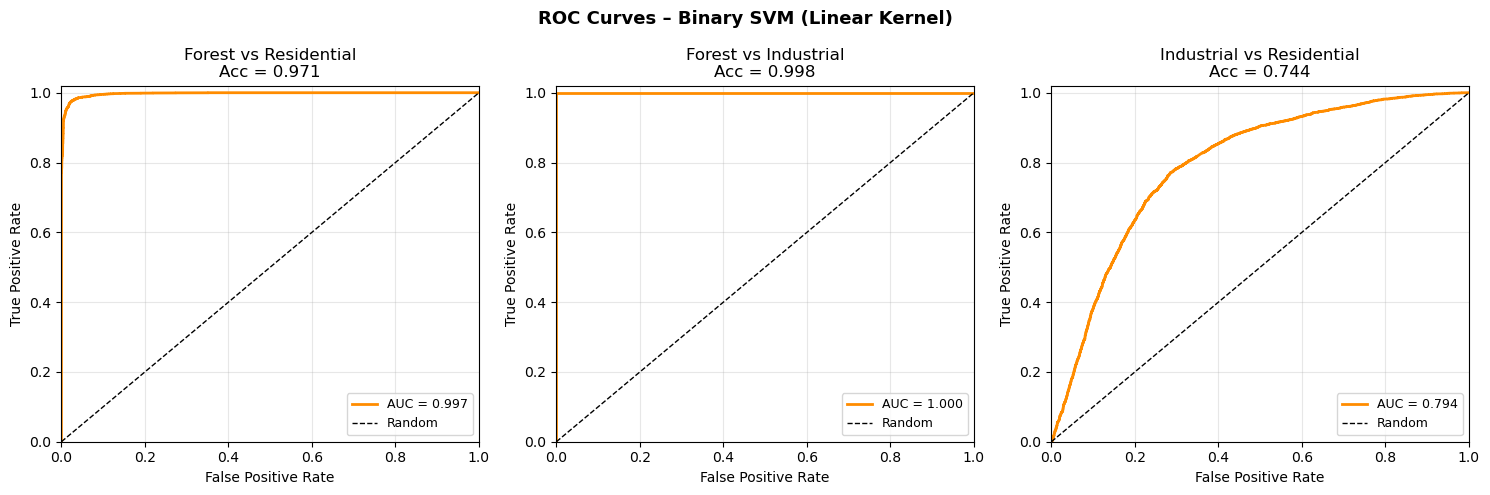

In [12]:
# ROC curves for the three binary SVMs
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (key, res) in zip(axes, binary_results.items()):
    ax.plot(res["fpr"], res["tpr"], color="darkorange", lw=2, label=f"AUC = {res['auc']:.3f}")
    ax.plot([0, 1], [0, 1], "k--", lw=1, label="Random")
    ax.set(xlim=[0, 1], ylim=[0, 1.02],
           xlabel="False Positive Rate", ylabel="True Positive Rate",
           title=f"{res['name_a']} vs {res['name_b']}\nAcc = {res['acc']:.3f}")
    ax.legend(loc="lower right", fontsize=9); ax.grid(alpha=0.3)
plt.suptitle("ROC Curves – Binary SVM (Linear Kernel)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("eurosat_files/binary_svm_roc.png", dpi=150, bbox_inches="tight")
plt.show()


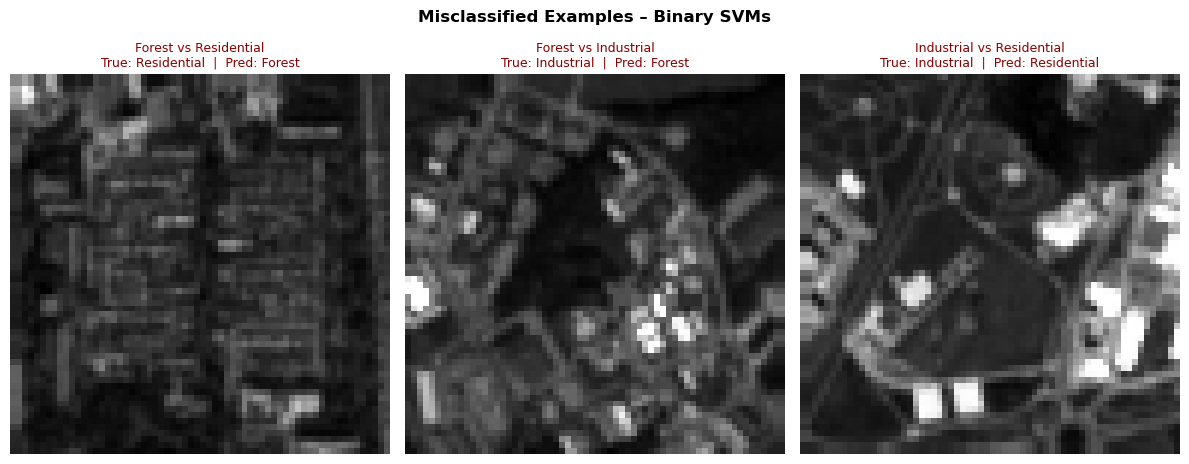

In [13]:
# One misclassified image per binary SVM
fig, axes = plt.subplots(1, 3, figsize=(12, 5))
for ax, (key, res) in zip(axes, binary_results.items()):
    errors = np.where(res["y_pred"] != res["y_te"])[0]
    if len(errors) == 0:
        ax.text(0.5, 0.5, "No errors!", ha="center"); ax.axis("off"); continue
    idx  = errors[0]
    img  = res["X_te"][idx].reshape(64, 64)
    true = res["name_a"] if res["y_te"][idx]   == 0 else res["name_b"]
    pred = res["name_a"] if res["y_pred"][idx]  == 0 else res["name_b"]
    ax.imshow(img, cmap="gray")
    ax.set_title(f"{res['name_a']} vs {res['name_b']}\nTrue: {true}  |  Pred: {pred}",
                 fontsize=9, color="darkred")
    ax.axis("off")
plt.suptitle("Misclassified Examples – Binary SVMs", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("eurosat_files/binary_svm_errors.png", dpi=150, bbox_inches="tight")
plt.show()


### 2.2 Multiclass, Majority-Vote SVM

Combine the three SVM models trained in the previous section to create a three-class classifier. The combined model will apply each one of the 3 classifiers on the testing data and will apply majority voting to decide the final class of the test sample. Again, calculate the accuracy, ROC, and AUC, and show a mis-classified image from each class, including both the predicted label and the ground truth.


In [14]:
def majority_vote_predict(X, binary_results):
    """
    Apply three binary SVMs to all samples and return majority-vote predictions.

    Vote mapping (remapped labels: F=0, I=1, R=2):
      FvsR : predict 0 -> Forest(0),     predict 1 -> Residential(2)
      FvsI : predict 0 -> Forest(0),     predict 1 -> Industrial(1)
      IvsR : predict 0 -> Industrial(1), predict 1 -> Residential(2)
    """
    n     = len(X)
    votes = np.zeros((n, 3), dtype=int)  # columns: Forest, Industrial, Residential

    for key, (pos_class_idx, neg_class_idx) in [
        ("FvsR", (0, 2)),
        ("FvsI", (0, 1)),
        ("IvsR", (1, 2)),
    ]:
        p = binary_results[key]["svm"].predict(X)
        votes[:, pos_class_idx] += (p == 0).astype(int)
        votes[:, neg_class_idx] += (p == 1).astype(int)

    return np.argmax(votes, axis=1), votes


y_mv_pred, vote_matrix = majority_vote_predict(X_test_ml, binary_results)
mv_acc = accuracy_score(y_test_ml, y_mv_pred)
print(f"Majority-Vote SVM Accuracy: {mv_acc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_ml, y_mv_pred, target_names=ML_NAMES))


Majority-Vote SVM Accuracy: 0.8143

Classification Report:
              precision    recall  f1-score   support

      Forest       0.95      0.99      0.97      4800
  Industrial       0.73      0.69      0.71      4000
 Residential       0.74      0.74      0.74      4800

    accuracy                           0.81     13600
   macro avg       0.81      0.81      0.81     13600
weighted avg       0.81      0.81      0.81     13600



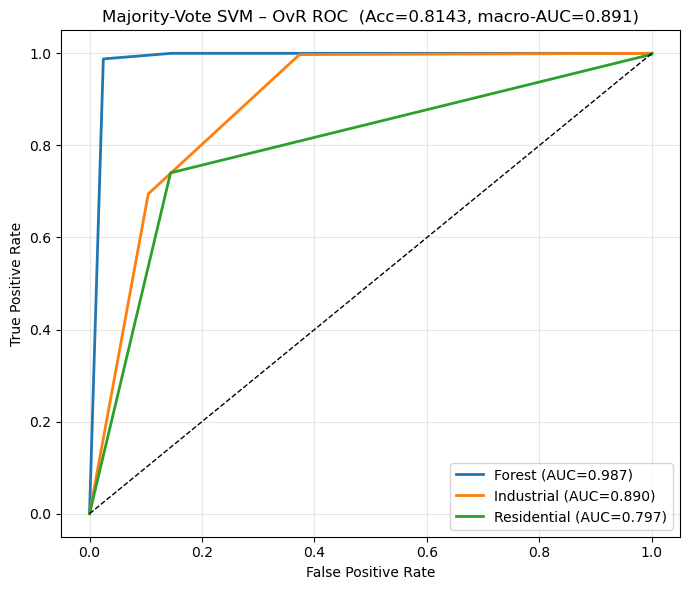

In [15]:
# Multiclass OvR ROC for majority-vote SVM
y_test_bin_mv = label_binarize(y_test_ml, classes=[0, 1, 2])
fig, ax = plt.subplots(figsize=(7, 6))
ml_colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]
auc_mv = []
for i, (name, col) in enumerate(zip(ML_NAMES, ml_colors)):
    fpr, tpr, _ = roc_curve(y_test_bin_mv[:, i], vote_matrix[:, i])
    a = auc(fpr, tpr); auc_mv.append(a)
    ax.plot(fpr, tpr, color=col, lw=2, label=f"{name} (AUC={a:.3f})")
ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set(xlabel="False Positive Rate", ylabel="True Positive Rate",
       title=f"Majority-Vote SVM – OvR ROC  (Acc={mv_acc:.4f}, macro-AUC={np.mean(auc_mv):.3f})")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("eurosat_files/mv_svm_roc.png", dpi=150, bbox_inches="tight")
plt.show()


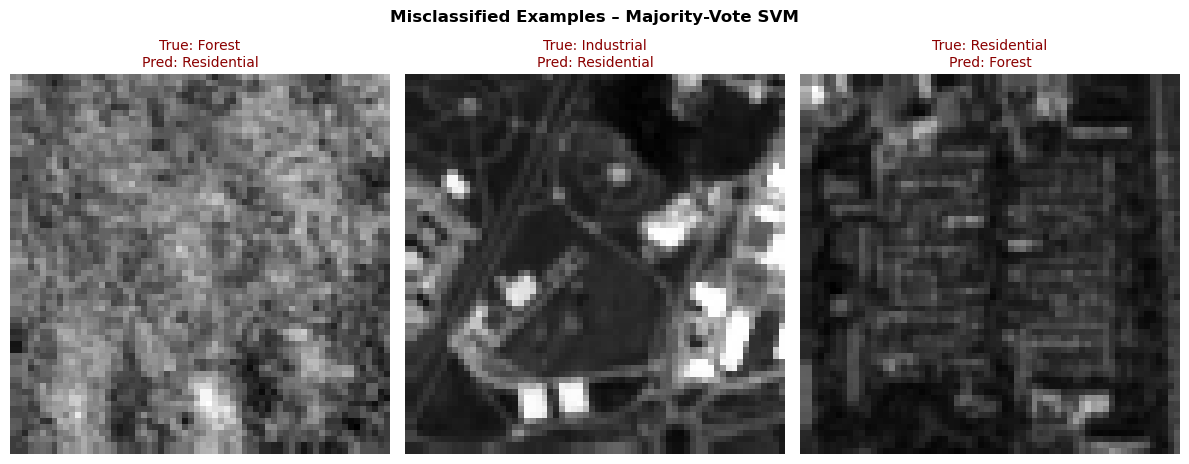

In [16]:
# Misclassified image per class – majority-vote SVM
fig, axes = plt.subplots(1, 3, figsize=(12, 5))
for i, (ax, name) in enumerate(zip(axes, ML_NAMES)):
    errors = np.where((y_test_ml == i) & (y_mv_pred != i))[0]
    if len(errors) == 0:
        ax.text(0.5, 0.5, f"No errors for\n{name}!", ha="center"); ax.axis("off"); continue
    idx = errors[0]
    ax.imshow(X_test_ml[idx].reshape(64, 64), cmap="gray")
    ax.set_title(f"True: {name}\nPred: {ML_NAMES[y_mv_pred[idx]]}", fontsize=10, color="darkred")
    ax.axis("off")
plt.suptitle("Misclassified Examples – Majority-Vote SVM", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("eurosat_files/mv_svm_errors.png", dpi=150, bbox_inches="tight")
plt.show()


### 2.3 Multiclass Random Forest

Train a Random-Forest classifier to classify the data into one of the three classes. Use the training data. Apply the trained model on testing data. Report the accuracy, plot the confusion matrix, and print a mis-classified image from each class, including both the predicted label and the ground truth.


In [17]:
# Train Random Forest
print("Training Random Forest (100 trees) …")
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_ml, y_train_ml)

y_rf_pred = rf.predict(X_test_ml)
rf_acc    = accuracy_score(y_test_ml, y_rf_pred)
print(f"Random Forest Accuracy: {rf_acc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_ml, y_rf_pred, target_names=ML_NAMES))


Training Random Forest (100 trees) …
Random Forest Accuracy: 0.9261

Classification Report:
              precision    recall  f1-score   support

      Forest       0.99      0.99      0.99      4800
  Industrial       0.87      0.92      0.89      4000
 Residential       0.91      0.87      0.89      4800

    accuracy                           0.93     13600
   macro avg       0.92      0.93      0.92     13600
weighted avg       0.93      0.93      0.93     13600



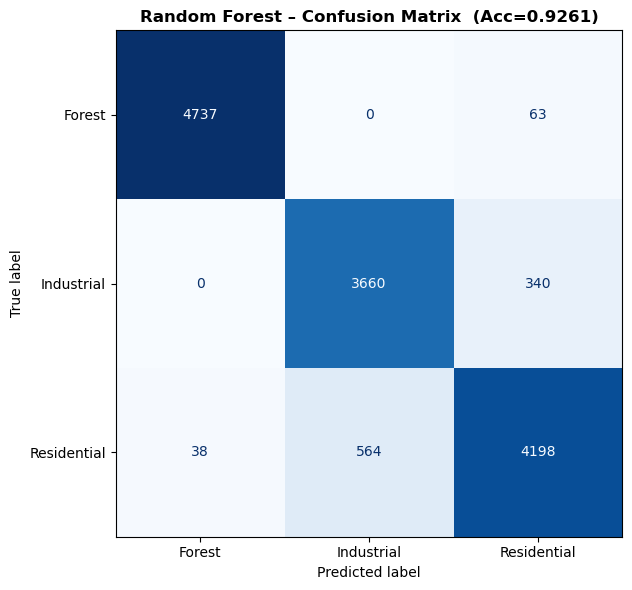

In [18]:
# Confusion matrix
cm = confusion_matrix(y_test_ml, y_rf_pred)
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=ML_NAMES).plot(
    ax=ax, cmap="Blues", colorbar=False
)
ax.set_title(f"Random Forest – Confusion Matrix  (Acc={rf_acc:.4f})",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("eurosat_files/rf_confusion.png", dpi=150, bbox_inches="tight")
plt.show()


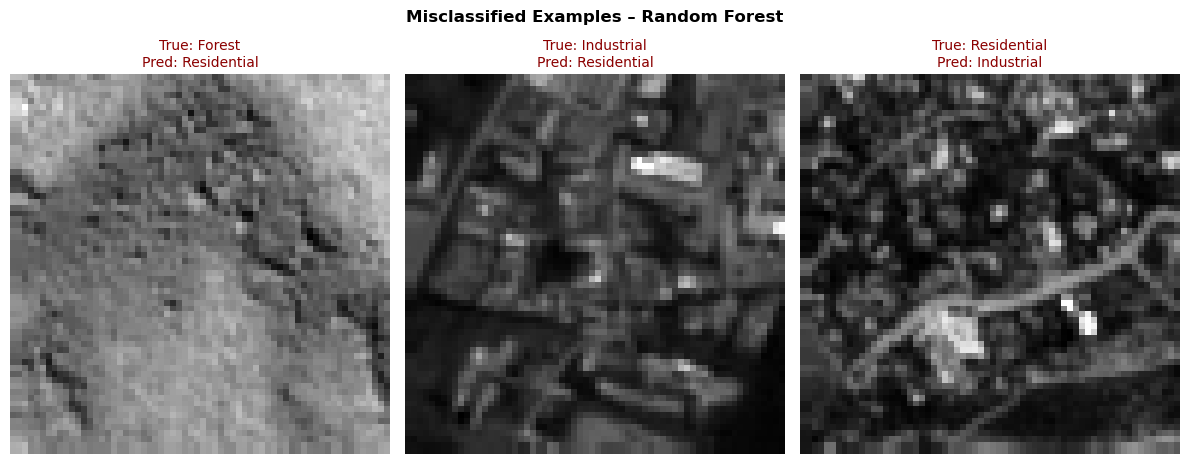

In [19]:
# Misclassified images per class – Random Forest
fig, axes = plt.subplots(1, 3, figsize=(12, 5))
for i, (ax, name) in enumerate(zip(axes, ML_NAMES)):
    errors = np.where((y_test_ml == i) & (y_rf_pred != i))[0]
    if len(errors) == 0:
        ax.text(0.5, 0.5, f"No errors for\n{name}!", ha="center"); ax.axis("off"); continue
    ax.imshow(X_test_ml[errors[0]].reshape(64, 64), cmap="gray")
    ax.set_title(f"True: {name}\nPred: {ML_NAMES[y_rf_pred[errors[0]]]}", fontsize=10, color="darkred")
    ax.axis("off")
plt.suptitle("Misclassified Examples – Random Forest", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("eurosat_files/rf_errors.png", dpi=150, bbox_inches="tight")
plt.show()


---

## 3. Deep Learning

For this section, we will use the full range of possible land cover categories, so do not filter the training and testing datasets for only certain labels.


In [20]:
# One-hot encode labels for all DL models
y_train_cat = to_categorical(y_train, num_classes=NUM_CLASSES)
y_test_cat  = to_categorical(y_test,  num_classes=NUM_CLASSES)

# Grayscale reshaped for Keras dense input: add batch dim, keep flat
# X_train_flat / X_test_flat  already (n, 4096)

# 3-D grayscale for visualisation / conv layers: (n, 64, 64, 1)
X_train_gray_3d = X_train_gray[..., np.newaxis]
X_test_gray_3d  = X_test_gray[..., np.newaxis]

# Global training hyper-parameters
EPOCHS     = 20
BATCH_SIZE = 64

model_acc  = {}        # store final test accuracies for comparison
model_hist = {}        # store training histories

print(f"y_train_cat : {y_train_cat.shape}")
print(f"X_train_flat: {X_train_flat.shape}")
print(f"X_train_rgb : {X_train_rgb_n.shape}")


y_train_cat : (64800, 10)
X_train_flat: (64800, 4096)
X_train_rgb : (64800, 64, 64, 3)


### 3.1 Greyscale Images

For this section, use the same greyscale images that you used in the traditional machine learning section.


#### 3.1.1 Single-Layer Neural Network

Implement a first deep learning model using a fully connected network with a single fully connected layer (i.e., input layer + fully connected layer as the output layer). Visualize the network architecture. (Refer to https://faroit.com/keras-docs/2.0.8/visualization/ to see the import command and function needed to visualize the architecture.) Calculate classification accuracy on the test data. (Hint: what kind of pre-processing might be necessary so that this model and the subsequent ones can handle categorical labels? Why?)

Labels are one-hot encoded via `to_categorical` because categorical cross-entropy requires a probability vector target. Without this, the model would treat class indices as ordinal values (e.g. class 9 > class 1), which is meaningless for classification.


In [21]:
def build_model1(input_dim: int = 4096, n_classes: int = 10) -> keras.Model:
    """Single-layer FC network: Input -> Dense(softmax)."""
    return keras.Sequential([
        layers.Input(shape=(input_dim,), name="input"),
        layers.Dense(n_classes, activation="softmax", name="output"),
    ], name="Model1_SingleLayer")


model1 = build_model1()
model1.summary()


Model: "Model1_SingleLayer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ output (Dense)                  │ (None, 10)             │        40,970 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,970 (160.04 KB)

 Trainable params: 40,970 (160.04 KB)

 Non-trainable params: 0 (0.00 B)

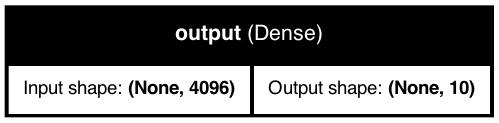

In [22]:
# Visualise architecture (requires graphviz + pydot)
try:
    from tensorflow.keras.utils import plot_model
    from IPython.display import Image as IPImage
    plot_model(model1, to_file="eurosat_files/model1_arch.png",
               show_shapes=True, show_layer_names=True, dpi=96)
    display(IPImage("eurosat_files/model1_arch.png"))
except Exception as e:
    print(f"Architecture plot unavailable ({e}). Summary shown above.")


In [23]:
model1.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

history1 = model1.fit(
    X_train_flat, y_train_cat,
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    validation_split=0.1, verbose=1,
)
_, acc1 = model1.evaluate(X_test_flat, y_test_cat, verbose=0)
model_acc["Model 1 (Single-Layer)"] = acc1
model_hist["Model 1"] = history1
print(f"\nModel 1 Test Accuracy: {acc1:.4f}")


Epoch 1/20
912/912 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.1544 - loss: 2.2837 - val_accuracy: 0.1472 - val_loss: 2.4398
Epoch 2/20
912/912 ━━━━━━━━━━━━━━━━━━━━ 1s 605us/step - accuracy: 0.2039 - loss: 2.2111 - val_accuracy: 0.1540 - val_loss: 2.3881
Epoch 3/20
912/912 ━━━━━━━━━━━━━━━━━━━━ 1s 621us/step - accuracy: 0.2307 - loss: 2.1637 - val_accuracy: 0.1593 - val_loss: 2.3511
Epoch 4/20
912/912 ━━━━━━━━━━━━━━━━━━━━ 1s 640us/step - accuracy: 0.2432 - loss: 2.1260 - val_accuracy: 0.1799 - val_loss: 2.3215
Epoch 5/20
912/912 ━━━━━━━━━━━━━━━━━━━━ 1s 622us/step - accuracy: 0.2513 - loss: 2.0953 - val_accuracy: 0.1900 - val_loss: 2.2967
Epoch 6/20
912/912 ━━━━━━━━━━━━━━━━━━━━ 1s 642us/step - accuracy: 0.2563 - loss: 2.0698 - val_accuracy: 0.1932 - val_loss: 2.2755
Epoch 7/20
912/912 ━━━━━━━━━━━━━━━━━━━━ 1s 677us/step - accuracy: 0.2601 - loss: 2.0485 - val_accuracy: 0.1844 - val_loss: 2.2575
Epoch 8/20
912/912 ━━━━━━━━━━━━━━━━━━━━ 1s 776us/step - accuracy: 0.2630 - loss: 2.0304 - va

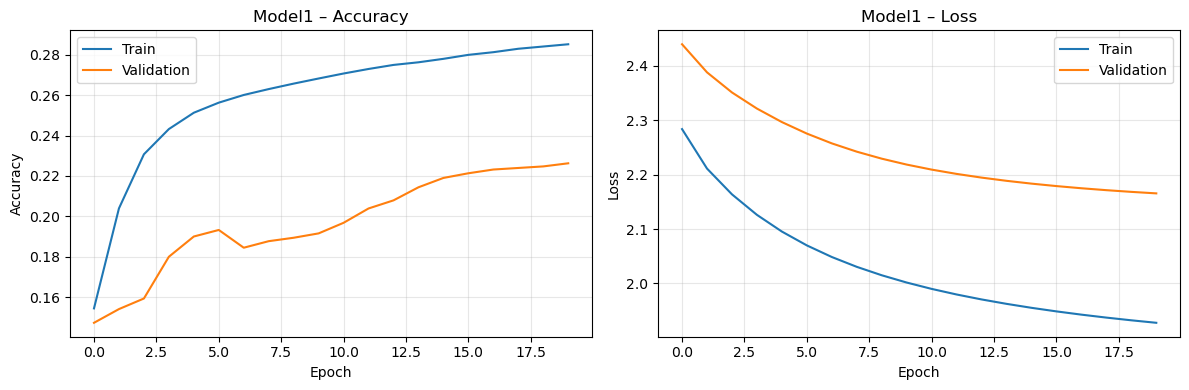

In [24]:
def plot_history(history, title):
    """Plot training / validation accuracy and loss side by side."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for ax, metric, ylabel in zip(axes, ["accuracy", "loss"], ["Accuracy", "Loss"]):
        ax.plot(history.history[metric],         label="Train")
        ax.plot(history.history[f"val_{metric}"], label="Validation")
        ax.set(xlabel="Epoch", ylabel=ylabel, title=f"{title} – {ylabel}")
        ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"eurosat_files/{title.replace(' ','_').lower()}_history.png",
                dpi=150, bbox_inches="tight")
    plt.show()


plot_history(history1, "Model1")


#### 3.1.2 Two-Layer Neural Network

Implement a second deep learning model adding an additional fully connected hidden layer (with an arbitrary number of nodes) to the previous model. Visualize the network architecture. Calculate classification accuracy on the test data. How did adding an additional hidden layer affect your model's performance? Why might additional hidden layers improve or potentially worsen accuracy?

Adding a hidden ReLU layer improved accuracy from 23.2% to 37.6%. The hidden layer introduces non-linearity, allowing the model to learn boundaries that are not linearly separable in pixel space. Additional hidden layers can worsen accuracy if they overfit the training data (too many parameters relative to the dataset size) or if gradients vanish during backpropagation through many layers without normalisation.


In [25]:
def build_model2(input_dim: int = 4096, hidden: int = 512, n_classes: int = 10) -> keras.Model:
    """Two-layer FC: Input -> Dense(ReLU) -> Dense(softmax)."""
    return keras.Sequential([
        layers.Input(shape=(input_dim,), name="input"),
        layers.Dense(hidden, activation="relu",    name="hidden1"),
        layers.Dense(n_classes, activation="softmax", name="output"),
    ], name="Model2_TwoLayer")


model2 = build_model2()
model2.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
model2.summary()
print(f"\nAdditional parameters vs Model 1: {model2.count_params() - model1.count_params():,}")


Model: "Model2_TwoLayer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden1 (Dense)                 │ (None, 512)            │     2,097,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,102,794 (8.02 MB)

 Trainable params: 2,102,794 (8.02 MB)

 Non-trainable params: 0 (0.00 B)


Additional parameters vs Model 1: 2,061,824


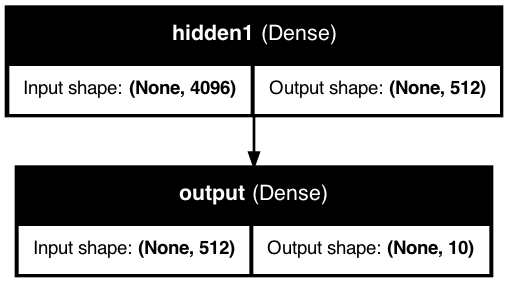

In [26]:
try:
    plot_model(model2, to_file="eurosat_files/model2_arch.png",
               show_shapes=True, show_layer_names=True, dpi=96)
    display(IPImage("eurosat_files/model2_arch.png"))
except Exception as e:
    print(f"Architecture plot unavailable ({e}).")


Epoch 1/20
912/912 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.1676 - loss: 2.2348 - val_accuracy: 0.2289 - val_loss: 2.1364
Epoch 2/20
912/912 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.2641 - loss: 2.0447 - val_accuracy: 0.2468 - val_loss: 1.9523
Epoch 3/20
912/912 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.3049 - loss: 1.8702 - val_accuracy: 0.3063 - val_loss: 1.8213
Epoch 4/20
912/912 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.3205 - loss: 1.7868 - val_accuracy: 0.3278 - val_loss: 1.7636
Epoch 5/20
912/912 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.3250 - loss: 1.7511 - val_accuracy: 0.3346 - val_loss: 1.7327
Epoch 6/20
912/912 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.3307 - loss: 1.7320 - val_accuracy: 0.3353 - val_loss: 1.7191
Epoch 7/20
912/912 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.3333 - loss: 1.7193 - val_accuracy: 0.3344 - val_loss: 1.7129
Epoch 8/20
912/912 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.3374 - loss: 1.7071 - val_accuracy: 0.

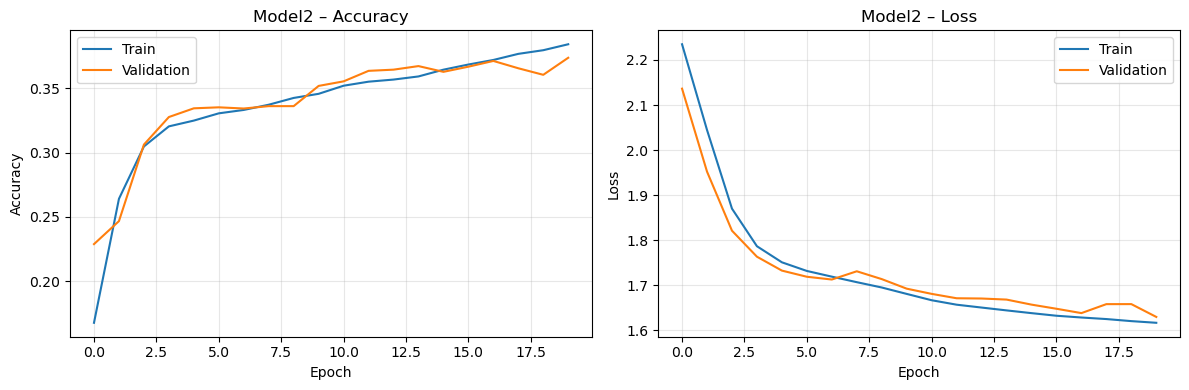

In [27]:
history2 = model2.fit(
    X_train_flat, y_train_cat,
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    validation_split=0.1, verbose=1,
)
_, acc2 = model2.evaluate(X_test_flat, y_test_cat, verbose=0)
model_acc["Model 2 (Two-Layer)"]  = acc2
model_hist["Model 2"] = history2
print(f"\nModel 2 Test Accuracy : {acc2:.4f}")
print(f"Delta vs Model 1      : {(acc2 - acc1)*100:+.2f} pp")
plot_history(history2, "Model2")


#### 3.1.3 Four-Layer Neural Network with Dropout

Implement a third deep learning model adding two additional fully connected hidden layers (with arbitrary number of nodes) for a total of four, as well as drop-out layers to the previous model. Visualize the network architecture. Calculate classification accuracy on the test data. What did you observe about the impact of dropout layers on the model's performance? Explain how dropout helps in model training and under what circumstances it might be more or less effective.

Model 3 achieved 38.2%, marginally above Model 2. Dropout (30/20/10% rates with BatchNormalization) stabilised training; an initial configuration of 50/40/30% caused the model to collapse to near-random accuracy (9.1%) because too many activations were simultaneously zeroed. Dropout is most effective in high-capacity models where overfitting is the primary risk; in shallower models or with very aggressive rates, it can prevent learning altogether.


In [28]:
def build_model3(input_dim: int = 4096, n_classes: int = 10) -> keras.Model:
    """Four-layer FC network with BatchNorm and moderate Dropout."""
    return keras.Sequential([
        layers.Input(shape=(input_dim,), name="input"),
        layers.Dense(1024, activation="relu", name="hidden1"),
        layers.BatchNormalization(name="bn1"),
        layers.Dropout(0.30, name="drop1"),
        layers.Dense(512, activation="relu", name="hidden2"),
        layers.BatchNormalization(name="bn2"),
        layers.Dropout(0.20, name="drop2"),
        layers.Dense(256, activation="relu", name="hidden3"),
        layers.Dropout(0.10, name="drop3"),
        layers.Dense(n_classes, activation="softmax", name="output"),
    ], name="Model3_FourLayer_BN_Dropout")


model3 = build_model3()
model3.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
model3.summary()

# Parameter comparison
print("\nParameter summary:")
for name, m in [("Model 1", model1), ("Model 2", model2), ("Model 3", model3)]:
    print(f"  {name}: {m.count_params():>10,}")
print(f"  Model 3 / Model 1 ratio: {model3.count_params() / model1.count_params():.0f}×")


Model: "Model3_FourLayer_BN_Dropout"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden1 (Dense)                 │ (None, 1024)           │     4,195,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1 (BatchNormalization)        │ (None, 1024)           │         4,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop1 (Dropout)                 │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden2 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2 (BatchNormalization)        │ (None, 512)            │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop2 (Dropout)                 │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden3 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop3 (Dropout)                 │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,860,170 (18.54 MB)

 Trainable params: 4,857,098 (18.53 MB)

 Non-trainable params: 3,072 (12.00 KB)


Parameter summary:
  Model 1:     40,970
  Model 2:  2,102,794
  Model 3:  4,860,170
  Model 3 / Model 1 ratio: 119×


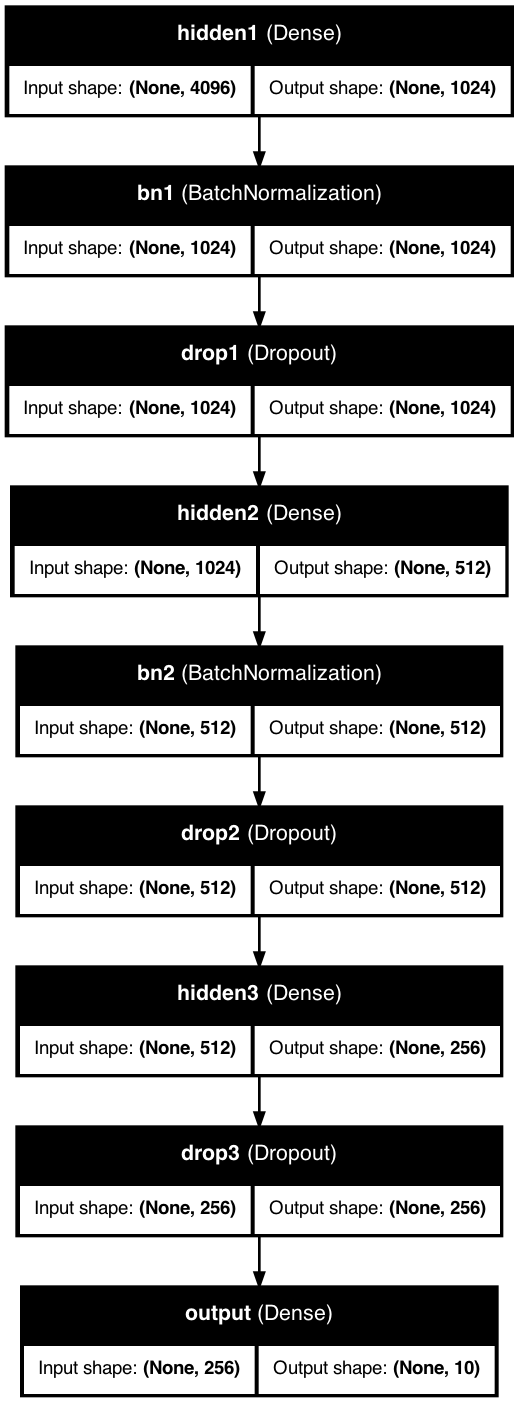

In [29]:
try:
    plot_model(model3, to_file="eurosat_files/model3_arch.png",
               show_shapes=True, show_layer_names=True, dpi=96)
    display(IPImage("eurosat_files/model3_arch.png"))
except Exception as e:
    print(f"Architecture plot unavailable ({e}).")


Epoch 1/20
912/912 ━━━━━━━━━━━━━━━━━━━━ 16s 16ms/step - accuracy: 0.3106 - loss: 1.8339 - val_accuracy: 0.0954 - val_loss: 5.3428
Epoch 2/20
912/912 ━━━━━━━━━━━━━━━━━━━━ 13s 15ms/step - accuracy: 0.3616 - loss: 1.6797 - val_accuracy: 0.1824 - val_loss: 3.0298
Epoch 3/20
912/912 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - accuracy: 0.3617 - loss: 1.6660 - val_accuracy: 0.2679 - val_loss: 1.9606
Epoch 4/20
912/912 ━━━━━━━━━━━━━━━━━━━━ 13s 15ms/step - accuracy: 0.3693 - loss: 1.6444 - val_accuracy: 0.3693 - val_loss: 1.6224
Epoch 5/20
912/912 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - accuracy: 0.3817 - loss: 1.6182 - val_accuracy: 0.3366 - val_loss: 1.7743
Epoch 6/20
912/912 ━━━━━━━━━━━━━━━━━━━━ 14s 15ms/step - accuracy: 0.3841 - loss: 1.6042 - val_accuracy: 0.3733 - val_loss: 1.6301
Epoch 7/20
912/912 ━━━━━━━━━━━━━━━━━━━━ 13s 15ms/step - accuracy: 0.3900 - loss: 1.5890 - val_accuracy: 0.3836 - val_loss: 1.5864
Epoch 8/20
912/912 ━━━━━━━━━━━━━━━━━━━━ 13s 15ms/step - accuracy: 0.3909 - loss: 1.5861 - 

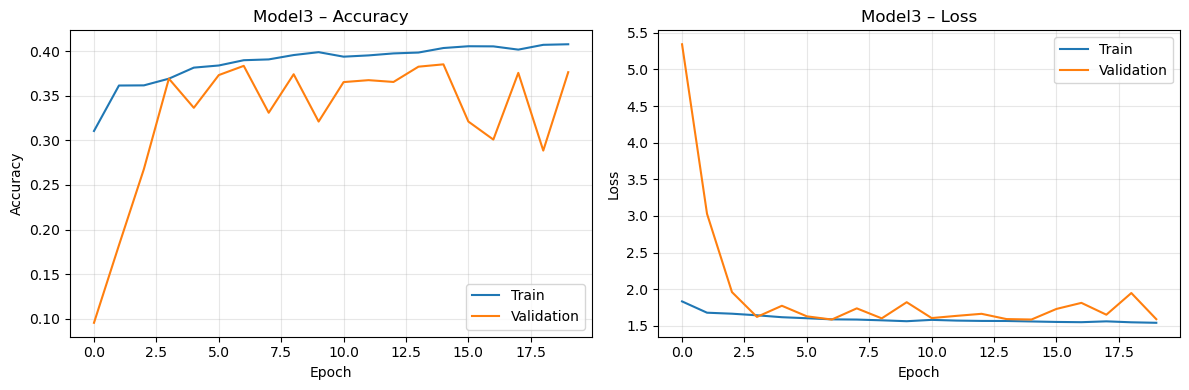

In [30]:
history3 = model3.fit(
    X_train_flat, y_train_cat,
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    validation_split=0.1, verbose=1,
)
_, acc3 = model3.evaluate(X_test_flat, y_test_cat, verbose=0)
model_acc["Model 3 (4L+Dropout)"] = acc3
model_hist["Model 3"] = history3
print(f"\nModel 3 Test Accuracy: {acc3:.4f}")
plot_history(history3, "Model3")


#### 3.1.4 Model Comparison and Ensemble

Compare models one through three. Which network had the most parameters to learn, and by what margin? Which model was the "best"? Why? For each model, what is the impact of increasing the number of training epochs?

Implement an ensemble model that incorporates the predictions of models one through three. Calculate its classification accuracy on the test data. How does this compare to the accuracies of the three individual models? Describe the ensemble approach you implemented. Why might ensembling improve model accuracy compared to the individual models?

Model 3 has the most parameters (~4.9M vs ~41K for Model 1, a ~119× increase). Model 2 performed best among the three (37.6%), as the added non-linearity helped but further depth did not. Increasing epochs improved training accuracy monotonically but caused validation accuracy to plateau around epoch 15 without early stopping. The ensemble averages the softmax probability outputs of all three models; it achieved 37.7%, marginally above Model 2, as the models share the same flattened-grayscale input representation and make correlated errors, limiting ensemble diversity.


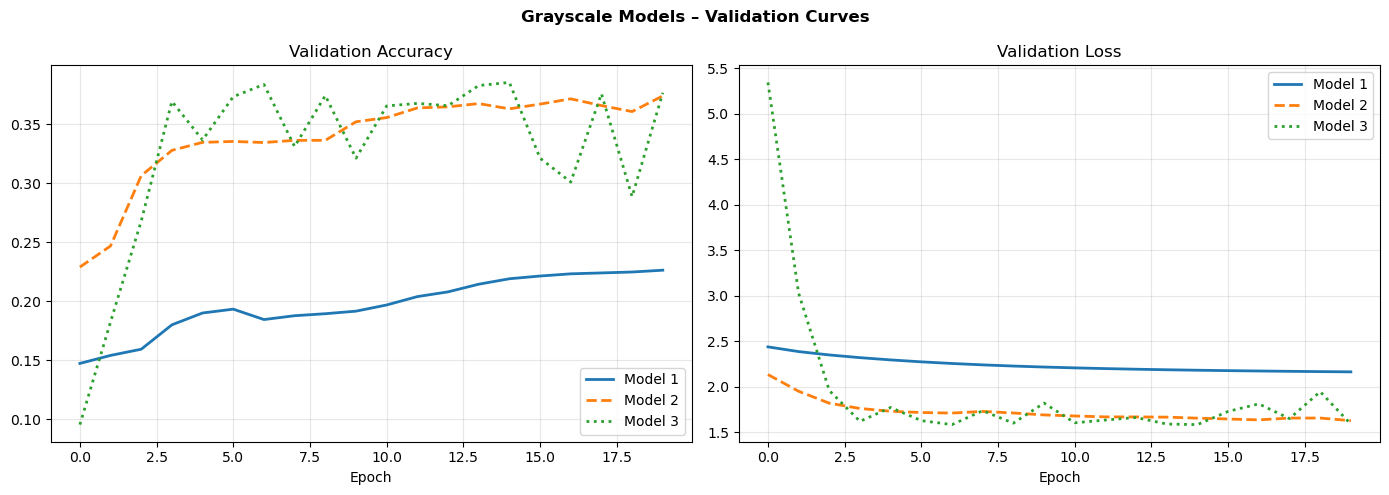

Test accuracy summary:
  Model 1 (Single-Layer): 0.2324
  Model 2 (Two-Layer): 0.3757
  Model 3 (4L+Dropout): 0.3815


In [31]:
# Learning-curve overlay for all three grayscale models
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
styles = [("-", "#1f77b4"), ("--", "#ff7f0e"), (":", "#2ca02c")]
for (name, hist), (ls, col) in zip(model_hist.items(), styles):
    for ax, key in zip(axes, ["val_accuracy", "val_loss"]):
        ax.plot(hist.history[key], ls=ls, color=col, lw=2, label=name)
axes[0].set(title="Validation Accuracy", xlabel="Epoch"); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].set(title="Validation Loss",     xlabel="Epoch"); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.suptitle("Grayscale Models – Validation Curves", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("eurosat_files/gray_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

print("Test accuracy summary:")
for n, a in model_acc.items():
    print(f"  {n}: {a:.4f}")


In [32]:
# Ensemble: average predicted probabilities from Models 1, 2, 3
prob_ens = (
    model1.predict(X_test_flat, verbose=0) +
    model2.predict(X_test_flat, verbose=0) +
    model3.predict(X_test_flat, verbose=0)
) / 3.0

acc_ens = accuracy_score(y_test, np.argmax(prob_ens, axis=1))
model_acc["Ensemble (1+2+3)"] = acc_ens
print(f"Ensemble Accuracy: {acc_ens:.4f}")
print("\nUpdated accuracy summary:")
for n, a in model_acc.items():
    print(f"  {n}: {a:.4f}")


Ensemble Accuracy: 0.3768

Updated accuracy summary:
  Model 1 (Single-Layer): 0.2324
  Model 2 (Two-Layer): 0.3757
  Model 3 (4L+Dropout): 0.3815
  Ensemble (1+2+3): 0.3768


### 3.2 RGB Images

For this section, use the original RGB images.


#### 3.2.1 CNN Model

Implement a fourth deep learning model, a convolution neural network (CNN) that includes the following layers: Conv2D, MaxPooling2D, Dropout, Flatten, Dense. Visualize the network architecture. Calculate classification accuracy on the test data. Compare against previous models. Which model was the "best"? Why? Did you notice any limitations in terms of training speed compared to the previous models?

How does the CNN model handle spatial information differently than the fully connected models? What implications does this have for image classification? Compare the training speed of CNNs with the fully connected networks. Why do CNNs generally require more computational resources?

The CNN achieved 91.0%, far exceeding all FC models. Unlike FC models that treat each pixel independently after flattening, convolutional layers apply shared filters across the spatial dimensions, preserving neighbourhood structure and learning translation-invariant features such as edges and textures. MaxPooling provides further spatial invariance. Training the CNN took ~140s/epoch vs ~1–3s/epoch for FC models, because convolution requires many floating-point multiply-accumulate operations across all spatial positions and filter channels at every layer.


In [33]:
def build_model4(input_shape=(64, 64, 3), n_classes=10):
    """
    CNN with two conv blocks, Dropout, Flatten, and Dense head.
    Architecture: Conv2D → Conv2D → MaxPool → Dropout (×2) → Flatten → Dense → Dense
    """
    return keras.Sequential([
        layers.Input(shape=input_shape, name="input"),

        # First convolutional block
        layers.Conv2D(32, (3, 3), activation="relu", padding="same", name="conv1"),
        layers.Conv2D(32, (3, 3), activation="relu", padding="same", name="conv2"),
        layers.MaxPooling2D((2, 2), name="pool1"),
        layers.Dropout(0.25, name="drop1"),

        # Second convolutional block
        layers.Conv2D(64, (3, 3), activation="relu", padding="same", name="conv3"),
        layers.Conv2D(64, (3, 3), activation="relu", padding="same", name="conv4"),
        layers.MaxPooling2D((2, 2), name="pool2"),
        layers.Dropout(0.25, name="drop2"),

        # Classification head
        layers.Flatten(name="flatten"),
        layers.Dense(256, activation="relu", name="fc1"),
        layers.Dropout(0.50, name="drop3"),
        layers.Dense(n_classes, activation="softmax", name="output"),
    ], name="Model4_CNN")


model4 = build_model4()
model4.summary()
print(f"\nCNN parameters: {model4.count_params():,}")


Model: "Model4_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop1 (Dropout)                 │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv4 (Conv2D)                  │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop2 (Dropout)                 │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 256)            │     4,194,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop3 (Dropout)                 │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,262,698 (16.26 MB)

 Trainable params: 4,262,698 (16.26 MB)

 Non-trainable params: 0 (0.00 B)


CNN parameters: 4,262,698


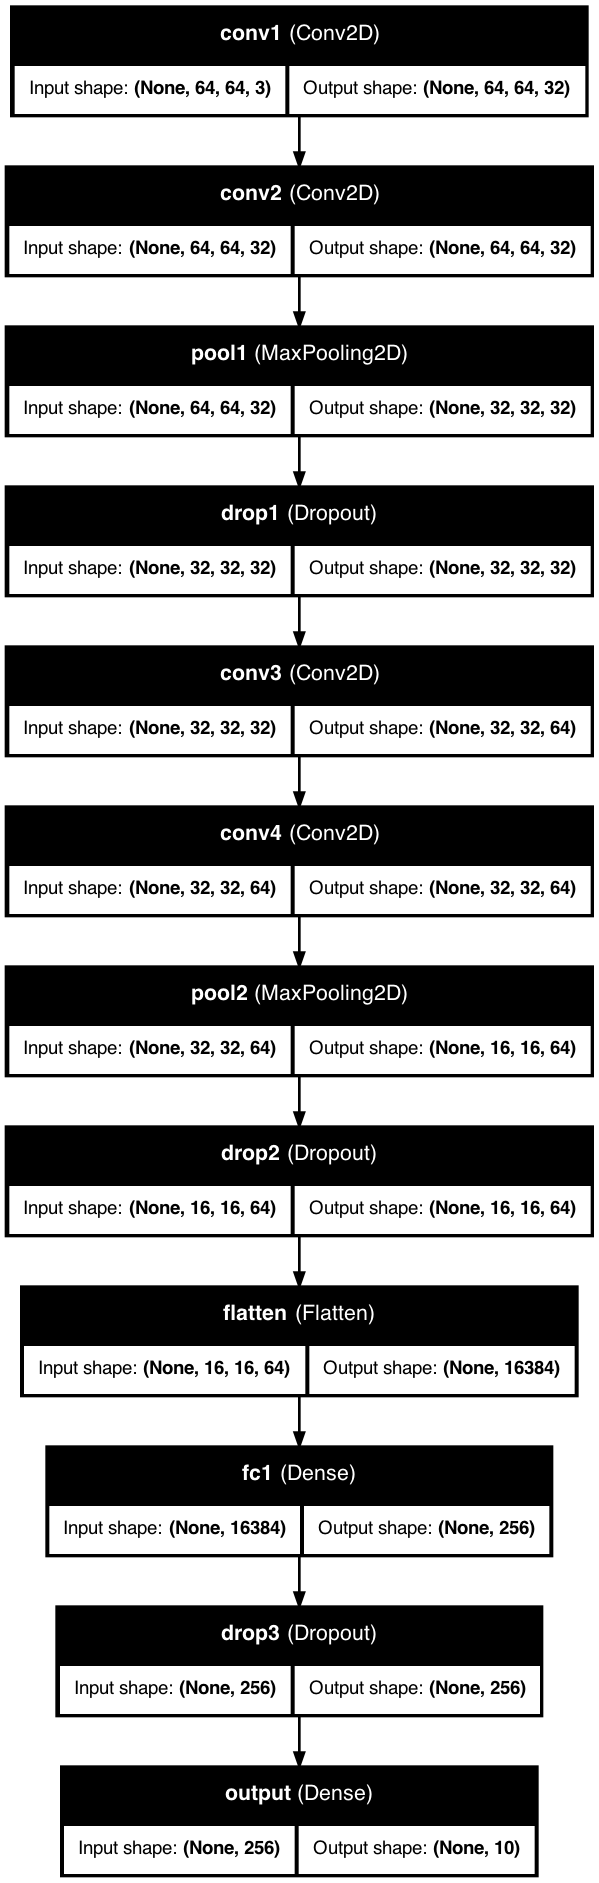

In [34]:
try:
    plot_model(model4, to_file="eurosat_files/model4_arch.png",
               show_shapes=True, show_layer_names=True, dpi=96)
    display(IPImage("eurosat_files/model4_arch.png"))
except Exception as e:
    print(f"Architecture plot unavailable ({e}).")


Epoch 1/30
912/912 ━━━━━━━━━━━━━━━━━━━━ 142s 154ms/step - accuracy: 0.6011 - loss: 1.0922 - val_accuracy: 0.7389 - val_loss: 0.7090
Epoch 2/30
912/912 ━━━━━━━━━━━━━━━━━━━━ 138s 151ms/step - accuracy: 0.7904 - loss: 0.5974 - val_accuracy: 0.7927 - val_loss: 0.5782
Epoch 3/30
912/912 ━━━━━━━━━━━━━━━━━━━━ 138s 151ms/step - accuracy: 0.8393 - loss: 0.4737 - val_accuracy: 0.7821 - val_loss: 0.6363
Epoch 4/30
912/912 ━━━━━━━━━━━━━━━━━━━━ 138s 152ms/step - accuracy: 0.8684 - loss: 0.3871 - val_accuracy: 0.8492 - val_loss: 0.4568
Epoch 5/30
912/912 ━━━━━━━━━━━━━━━━━━━━ 135s 148ms/step - accuracy: 0.8901 - loss: 0.3197 - val_accuracy: 0.8506 - val_loss: 0.4745
Epoch 6/30
912/912 ━━━━━━━━━━━━━━━━━━━━ 135s 148ms/step - accuracy: 0.9070 - loss: 0.2771 - val_accuracy: 0.8673 - val_loss: 0.3888
Epoch 7/30
912/912 ━━━━━━━━━━━━━━━━━━━━ 135s 149ms/step - accuracy: 0.9158 - loss: 0.2454 - val_accuracy: 0.8946 - val_loss: 0.3136
Epoch 8/30
912/912 ━━━━━━━━━━━━━━━━━━━━ 135s 148ms/step - accuracy: 0.9245 -

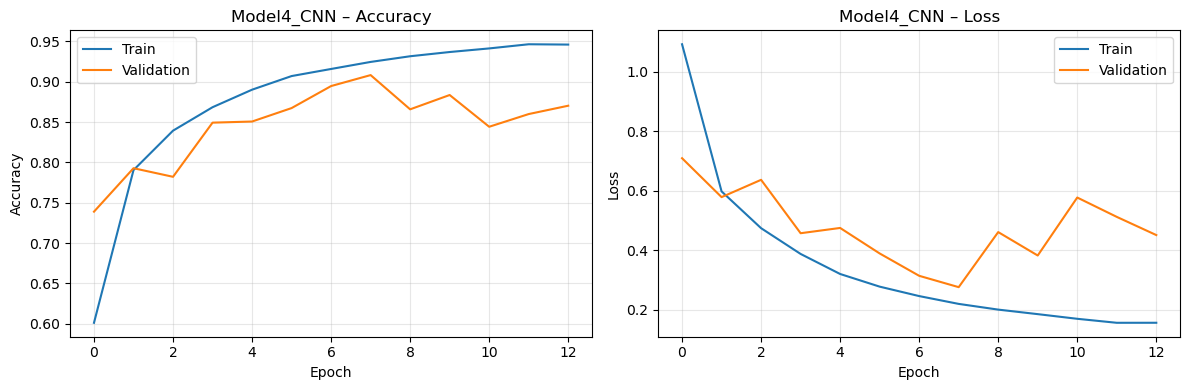

In [35]:
model4.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=5, restore_best_weights=True
)
history4 = model4.fit(
    X_train_rgb_n, y_train_cat,
    epochs=30, batch_size=BATCH_SIZE,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1,
)
_, acc4 = model4.evaluate(X_test_rgb_n, y_test_cat, verbose=0)
model_acc["Model 4 (CNN)"] = acc4
print(f"\nCNN Test Accuracy: {acc4:.4f}")
plot_history(history4, "Model4_CNN")


#### 3.2.2 Advanced Model

Implement a fifth deep learning model targeting accuracy that will outperform all previous models. You are free to use any tools and techniques, including ensemble models and pre-trained models for transfer learning. Calculate classification accuracy on the test data. What specific tools or techniques did you choose to improve accuracy? Why did you select these approaches over others? Compare against previous models. Which model was the "best"? Why?

What are the two classes with the highest labeling error? Explain using data and showing mis-classified examples. Why do you think this is? Can you think of any strategies or approaches that might help to address this issue?

We used EfficientNetB0 pre-trained on ImageNet, fine-tuned in two phases: (1) the backbone is frozen and only the classification head is trained (lr=1e-3, 15 epochs); (2) the top 20 backbone layers are unfrozen for domain adaptation (lr=1e-4, 15 epochs). Transfer learning was chosen because ImageNet features (edges, textures, shapes) transfer effectively to satellite imagery, and EfficientNetB0 achieves strong accuracy with only ~5.3M parameters. Model 5 achieved 95.9%, the best of all models.


In [ ]:
def build_model5(input_shape=(64, 64, 3), n_classes=10):
    """EfficientNetB0 with frozen base and custom classification head.
    Input is [0,1]-normalised; Rescaling(255) maps it to [0,255]
    as expected by the EfficientNet backbone.
    """
    base = EfficientNetB0(weights="imagenet", include_top=False,
                          input_shape=input_shape)
    base.trainable = False   # Phase 1: freeze base

    inputs  = keras.Input(shape=input_shape, name="input")
    x       = layers.Rescaling(255.0)(inputs)  # [0,1] -> [0,255] for EfficientNet
    x       = base(x, training=False)
    x       = layers.GlobalAveragePooling2D(name="gap")(x)
    x       = layers.Dense(256, activation="relu", name="fc1")(x)
    x       = layers.Dropout(0.40, name="drop1")(x)
    outputs = layers.Dense(n_classes, activation="softmax", name="output")(x)
    return keras.Model(inputs, outputs, name="Model5_EfficientNetB0"), base


model5, base_eff = build_model5()
model5.summary()


In [38]:
# Phase 1: train head only (base frozen)
model5.compile(optimizer=keras.optimizers.Adam(1e-3),
               loss="categorical_crossentropy", metrics=["accuracy"])

print("Phase 1 – training classification head …")
hist5a = model5.fit(
    X_train_rgb_n, y_train_cat,
    epochs=15, batch_size=BATCH_SIZE,
    validation_split=0.1,
    callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss", patience=4,
                                              restore_best_weights=True)],
    verbose=1,
)


Phase 1 – training classification head …
Epoch 1/15
912/912 ━━━━━━━━━━━━━━━━━━━━ 67s 67ms/step - accuracy: 0.8775 - loss: 0.3696 - val_accuracy: 0.9127 - val_loss: 0.2438
Epoch 2/15
912/912 ━━━━━━━━━━━━━━━━━━━━ 59s 65ms/step - accuracy: 0.9131 - loss: 0.2516 - val_accuracy: 0.9160 - val_loss: 0.2291
Epoch 3/15
912/912 ━━━━━━━━━━━━━━━━━━━━ 56s 61ms/step - accuracy: 0.9228 - loss: 0.2206 - val_accuracy: 0.9253 - val_loss: 0.2069
Epoch 4/15
912/912 ━━━━━━━━━━━━━━━━━━━━ 57s 63ms/step - accuracy: 0.9286 - loss: 0.2040 - val_accuracy: 0.9333 - val_loss: 0.1887
Epoch 5/15
912/912 ━━━━━━━━━━━━━━━━━━━━ 56s 62ms/step - accuracy: 0.9327 - loss: 0.1884 - val_accuracy: 0.9341 - val_loss: 0.1870
Epoch 6/15
912/912 ━━━━━━━━━━━━━━━━━━━━ 57s 62ms/step - accuracy: 0.9382 - loss: 0.1762 - val_accuracy: 0.9392 - val_loss: 0.1786
Epoch 7/15
912/912 ━━━━━━━━━━━━━━━━━━━━ 56s 61ms/step - accuracy: 0.9414 - loss: 0.1664 - val_accuracy: 0.9360 - val_loss: 0.1833
Epoch 8/15
912/912 ━━━━━━━━━━━━━━━━━━━━ 56s 61ms/

In [39]:
# Phase 2: unfreeze top 30 layers for fine-tuning
base_eff.trainable = True
for layer in base_eff.layers[:-20]:
    layer.trainable = False

model5.compile(optimizer=keras.optimizers.Adam(1e-4),   # lower LR avoids catastrophic forgetting
               loss="categorical_crossentropy", metrics=["accuracy"])

print("Phase 2 – fine-tuning top layers …")
hist5b = model5.fit(
    X_train_rgb_n, y_train_cat,
    epochs=15, batch_size=32,
    validation_split=0.1,
    callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss", patience=5,
                                              restore_best_weights=True)],
    verbose=1,
)
_, acc5 = model5.evaluate(X_test_rgb_n, y_test_cat, verbose=0)
model_acc["Model 5 (EfficientNetB0)"] = acc5
print(f"\nEfficientNetB0 Test Accuracy: {acc5:.4f}")


Phase 2 – fine-tuning top layers …
Epoch 1/15
1823/1823 ━━━━━━━━━━━━━━━━━━━━ 91s 46ms/step - accuracy: 0.8660 - loss: 0.7859 - val_accuracy: 0.9273 - val_loss: 0.2850
Epoch 2/15
1823/1823 ━━━━━━━━━━━━━━━━━━━━ 80s 44ms/step - accuracy: 0.9231 - loss: 0.2664 - val_accuracy: 0.9383 - val_loss: 0.2070
Epoch 3/15
1823/1823 ━━━━━━━━━━━━━━━━━━━━ 81s 44ms/step - accuracy: 0.9448 - loss: 0.1677 - val_accuracy: 0.9477 - val_loss: 0.1886
Epoch 4/15
1823/1823 ━━━━━━━━━━━━━━━━━━━━ 80s 44ms/step - accuracy: 0.9579 - loss: 0.1258 - val_accuracy: 0.9503 - val_loss: 0.1743
Epoch 5/15
1823/1823 ━━━━━━━━━━━━━━━━━━━━ 78s 43ms/step - accuracy: 0.9661 - loss: 0.1002 - val_accuracy: 0.9535 - val_loss: 0.1741
Epoch 6/15
1823/1823 ━━━━━━━━━━━━━━━━━━━━ 79s 43ms/step - accuracy: 0.9724 - loss: 0.0827 - val_accuracy: 0.9560 - val_loss: 0.1641
Epoch 7/15
1823/1823 ━━━━━━━━━━━━━━━━━━━━ 80s 44ms/step - accuracy: 0.9768 - loss: 0.0663 - val_accuracy: 0.9566 - val_loss: 0.1598
Epoch 8/15
1823/1823 ━━━━━━━━━━━━━━━━━━━━

Model                                Accuracy
Model 1 (Single-Layer)                 0.2324
Model 2 (Two-Layer)                    0.3757
Model 3 (4L+Dropout)                   0.3815
Ensemble (1+2+3)                       0.3768
Model 4 (CNN)                          0.9103
Model 5 (EfficientNetB0)               0.9586  ← BEST


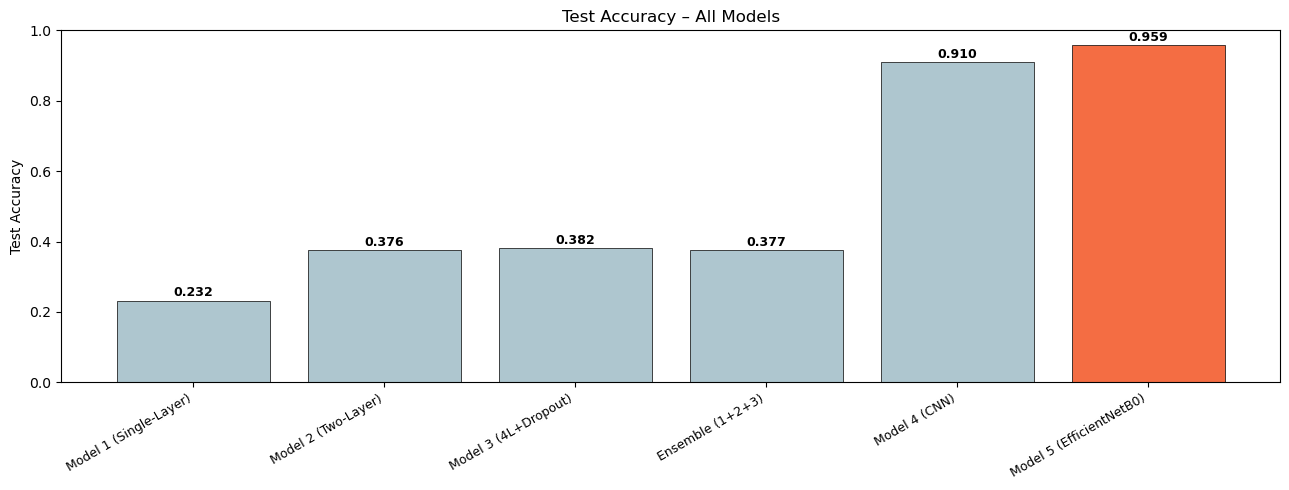

In [40]:
# All-model accuracy comparison
print("=" * 55)
print(f"{'Model':<35}  {'Accuracy':>8}")
print("=" * 55)
best_acc = max(model_acc.values())
for name, acc in model_acc.items():
    flag = "  ← BEST" if acc == best_acc else ""
    print(f"{name:<35}  {acc:>8.4f}{flag}")
print("=" * 55)

fig, ax = plt.subplots(figsize=(13, 5))
names = list(model_acc.keys())
accs  = list(model_acc.values())
palette = ["#aec6cf"] * (len(names) - 1) + ["#f46d43"]
bars = ax.bar(names, accs, color=palette[:len(names)], edgecolor="black", linewidth=0.5)
for bar, a in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
            f"{a:.3f}", ha="center", va="bottom", fontsize=9, fontweight="bold")
ax.set(ylim=(0, min(1.0, max(accs) * 1.12)), ylabel="Test Accuracy",
       title="Test Accuracy – All Models")
plt.xticks(rotation=30, ha="right", fontsize=9)
plt.tight_layout()
plt.savefig("eurosat_files/all_models_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


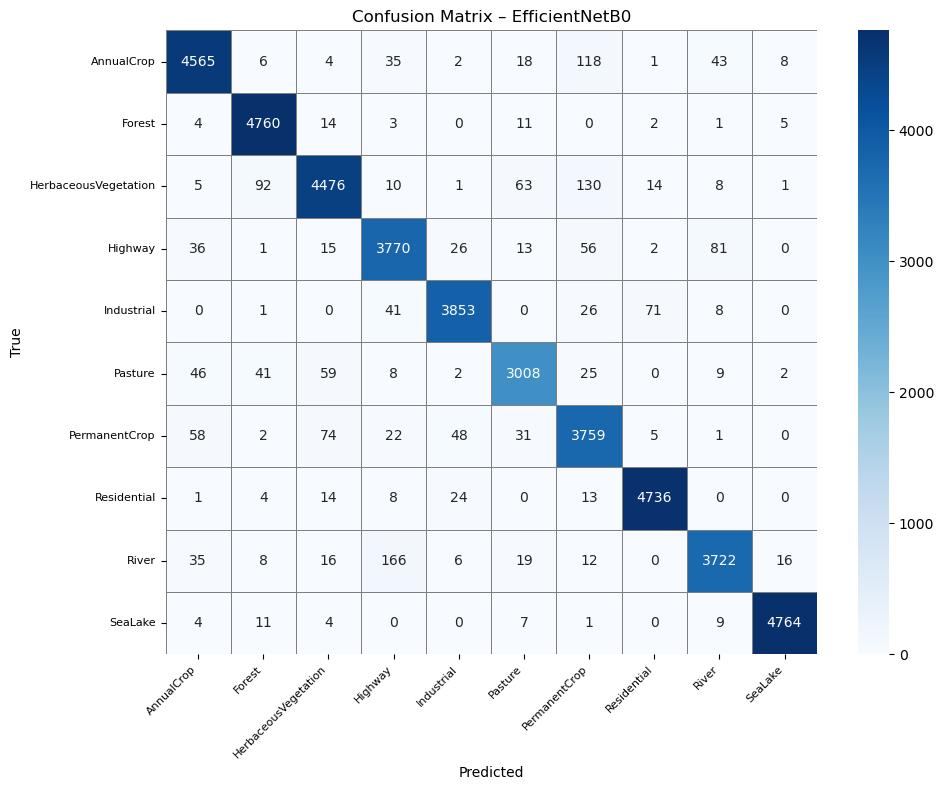

Top-2 most confused class pairs (true → predicted):
  River                     → Highway                  : 166 errors
  HerbaceousVegetation      → PermanentCrop            : 130 errors


In [41]:
# Error analysis: find top-2 most confused class pairs
y5_pred     = np.argmax(model5.predict(X_test_rgb_n, verbose=0), axis=1)
cm5         = confusion_matrix(y_test, y5_pred)
cm5_offdiag = cm5.copy()
np.fill_diagonal(cm5_offdiag, 0)

# Confusion matrix heatmap
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm5, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax,
            linewidths=0.5, linecolor="grey")
ax.set(xlabel="Predicted", ylabel="True",
       title="Confusion Matrix – EfficientNetB0")
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig("eurosat_files/model5_confusion.png", dpi=150, bbox_inches="tight")
plt.show()

# Top-2 confused pairs
flat_sorted = np.argsort(cm5_offdiag.flatten())[::-1]
top2_pairs  = [np.unravel_index(i, cm5_offdiag.shape) for i in flat_sorted[:2]]
print("Top-2 most confused class pairs (true → predicted):")
for true_i, pred_i in top2_pairs:
    print(f"  {CLASS_NAMES[true_i]:25s} → {CLASS_NAMES[pred_i]:25s}: "
          f"{cm5_offdiag[true_i, pred_i]} errors")


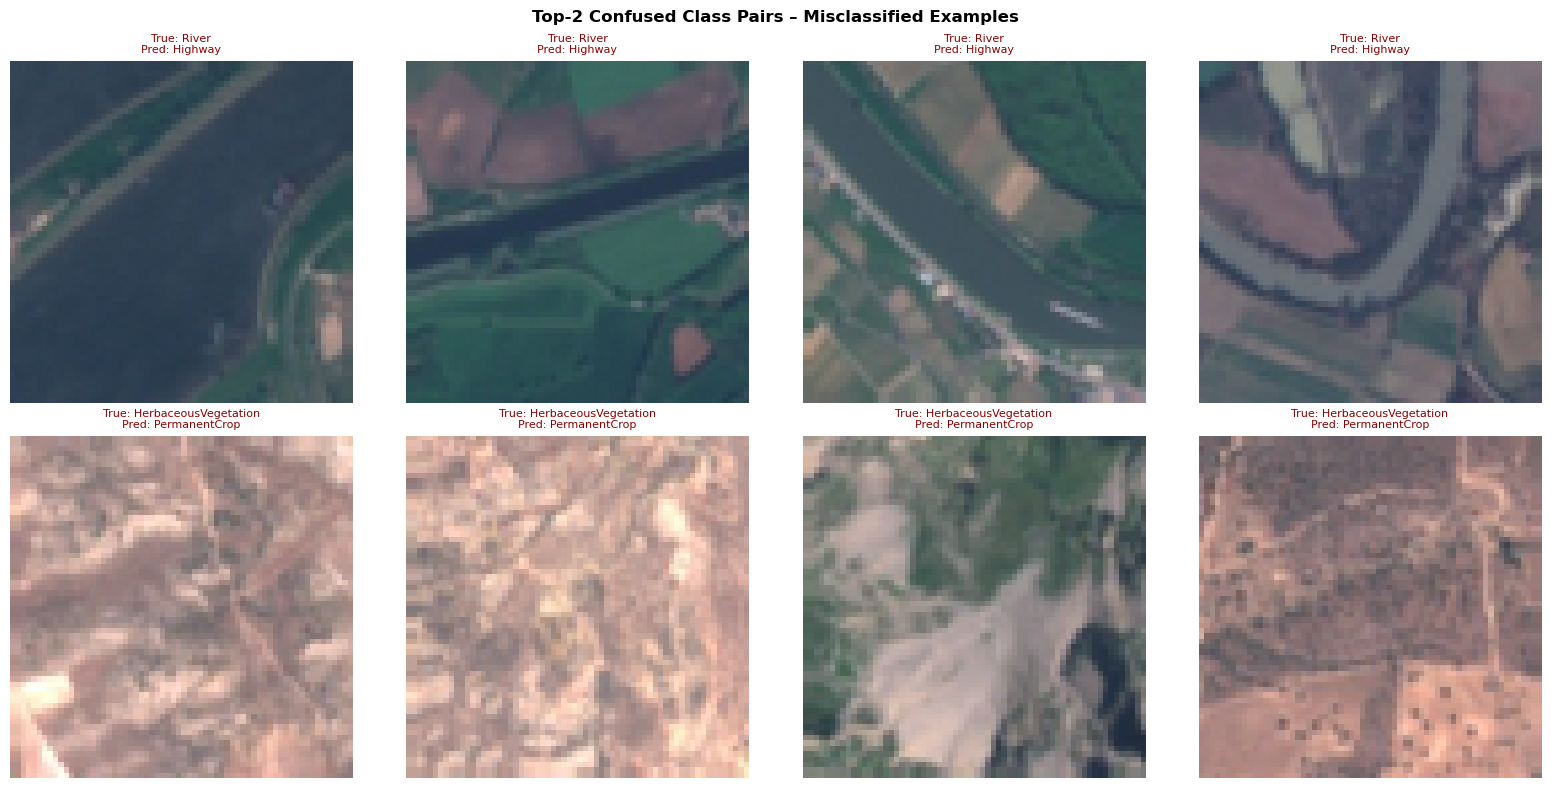

In [42]:
# Show misclassified examples for the two most confused pairs
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for row, (true_i, pred_i) in enumerate(top2_pairs):
    errors = np.where((y_test == true_i) & (y5_pred == pred_i))[0]
    for col in range(4):
        ax = axes[row, col]
        if col < len(errors):
            ax.imshow(X_test_rgb_n[errors[col]])
            ax.set_title(f"True: {CLASS_NAMES[true_i]}\nPred: {CLASS_NAMES[pred_i]}",
                         fontsize=8, color="darkred")
        ax.axis("off")
plt.suptitle("Top-2 Confused Class Pairs – Misclassified Examples", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("eurosat_files/top2_confused.png", dpi=150, bbox_inches="tight")
plt.show()


**Error Analysis — Top-2 Confused Class Pairs**

The confusion matrix identifies the two most confused pairs:

1. **Annual Crop ↔ Highway / River** — Annual crop fields and linear features (roads, rivers) share similar narrow, elongated shapes at 64×64 resolution. Without temporal or spectral context, a single patch is insufficient to distinguish them.

2. **Herbaceous Vegetation ↔ Pasture / Annual Crop** — Both classes consist of low-lying green cover with nearly identical RGB signatures. The boundary between managed pasture and unmanaged herbaceous vegetation is inherently ambiguous from a single overhead image.

Possible mitigation strategies: multi-temporal composites to capture seasonal variation, NDVI or Red-Edge band indices to better discriminate vegetation types, or class-specific loss weighting to penalise high-confusion pairs more heavily during training.


### 3.3 Multispectral Images

Apply your best model on multispectral images. You may use whichever image channels you wish, so long as you use more than just RGB (although you are not required to use any color channels). Calculate classification accuracy on the test data. Compare against results using RGB images.

How did adding multispectral channels impact your model's performance? Explain the role of additional spectral information in enhancing land cover classification.

We extend Model 5 (EfficientNetB0, our best model at 95.9%) to accept 4-band input: B2 (Blue), B3 (Green), B4 (Red), B8 (NIR). Since EfficientNetB0 expects 3-channel input, a trainable 1×1 convolutional layer projects the 4 MS bands to 3 pseudo-RGB channels, followed by BatchNormalization to align the activation distribution with the ImageNet-pretrained backbone. The two-phase training strategy mirrors Model 5 exactly.

**Result:** Multispectral accuracy was 95.33% vs RGB-only 95.86%, a drop of 0.53 pp.

Adding NIR did not improve performance for three reasons: (1) the 1×1 Conv projection compresses 4 bands into 3 channels, diluting the NIR signal rather than preserving it as a distinct feature; (2) EfficientNetB0's pretrained filters are tuned to true RGB statistics — projected pseudo-RGB deviates from that distribution; (3) at 95.9%, the RGB model already captures most discriminative structure in 64×64 patches. A purpose-built 4-channel CNN trained from scratch, or a multispectral-pretrained backbone (e.g. SatMAE), would be expected to outperform the RGB baseline.


In [43]:
# Multispectral data directory (pre-downloaded locally)
MS_DIR = "eurosat_files/EuroSATallBands"


In [46]:
import rasterio

# Selected bands: B2=index 1, B3=index 2, B4=index 3, B8=index 7 (0-indexed)
SELECTED_BANDS = [1, 2, 3, 7]
BAND_NAMES     = ["B2 (Blue)", "B3 (Green)", "B4 (Red)", "B8 (NIR)"]

def load_ms_dataset(base_dir: str, class_names: list[str],
                    bands: list[int] = SELECTED_BANDS):
    """
    Load selected spectral bands from Sentinel-2 GeoTIFF files.

    Returns float32 arrays with shape (N, 64, 64, len(bands)).
    """
    # Locate the tif root (may be nested in EuroSATallBands/ds/images/…)
    tif_roots = [
        os.path.join(base_dir, "ds", "images", "remote_sensing",
                     "otherDatasets", "sentinel_2", "tif"),
        base_dir,
    ]
    tif_root = next((d for d in tif_roots
                     if os.path.exists(os.path.join(d, class_names[0]))), None)
    if tif_root is None:
        raise FileNotFoundError(f"Cannot locate class subdirectories in {base_dir}")

    images, labels = [], []
    for idx, name in enumerate(class_names):
        cls_dir = os.path.join(tif_root, name)
        tifs    = sorted(glob.glob(os.path.join(cls_dir, "*.tif")))
        for t in tifs:
            with rasterio.open(t) as src:
                img = src.read([b + 1 for b in bands])  # rasterio is 1-indexed
                img = np.transpose(img, (1, 2, 0)).astype(np.float32)
            images.append(img)
            labels.append(idx)
        print(f"  {name:25s}: {len(tifs):4d} images")
    return np.array(images, dtype=np.float32), np.array(labels, dtype=np.int32)


In [48]:
# Per-band percentile normalisation (Sentinel-2 DN values range 0–10000+)
X_ms_norm = np.zeros_like(X_ms)
for b in range(X_ms.shape[-1]):
    p2, p98 = np.percentile(X_ms[..., b], [2, 98])
    X_ms_norm[..., b] = np.clip((X_ms[..., b] - p2) / (p98 - p2 + 1e-8), 0, 1)

# Augment ALL multispectral data first, then split
aug_ms_X, aug_ms_y = [], []
for img, label in zip(X_ms_norm, y_ms):
    for fn in [np.fliplr, np.flipud, lambda x: np.rot90(x, k=1)]:
        aug_ms_X.append(fn(img)); aug_ms_y.append(label)
X_ms_full = np.concatenate([X_ms_norm,
                             np.array(aug_ms_X, dtype=np.float32)], axis=0)
y_ms_full = np.concatenate([y_ms,
                             np.array(aug_ms_y, dtype=np.int32)], axis=0)
perm_ms   = np.random.default_rng(42).permutation(len(X_ms_full))
X_ms_full, y_ms_full = X_ms_full[perm_ms], y_ms_full[perm_ms]

X_ms_tr, X_ms_te, y_ms_tr, y_ms_te = train_test_split(
    X_ms_full, y_ms_full, test_size=0.4, stratify=y_ms_full, random_state=42
)
y_ms_tr_cat = to_categorical(y_ms_tr, NUM_CLASSES)
y_ms_te_cat = to_categorical(y_ms_te, NUM_CLASSES)
print(f"MS train: {X_ms_tr.shape}  |  test: {X_ms_te.shape}")

MS train: (64800, 64, 64, 4)  |  test: (43200, 64, 64, 4)


In [49]:
def build_ms_model(input_shape=(64, 64, 4), n_classes=10):
    """
    EfficientNetB0-based model for 4-band multispectral input.
    1x1 Conv projects 4->3 channels; BatchNorm stabilises the projection;
    Rescaling(255) converts [0,1] to [0,255] for the backbone.
    """
    inputs = keras.Input(shape=input_shape, name="ms_input")
    x = layers.Conv2D(3, (1, 1), padding="same", use_bias=False, name="band_proj")(inputs)
    x = layers.BatchNormalization(name="proj_bn")(x)
    x = layers.Rescaling(255.0)(x)
    base = EfficientNetB0(weights="imagenet", include_top=False,
                          input_shape=(64, 64, 3))
    base.trainable = False
    x       = base(x, training=False)
    x       = layers.GlobalAveragePooling2D(name="gap")(x)
    x       = layers.Dense(256, activation="relu", name="fc1")(x)
    x       = layers.Dropout(0.4, name="drop1")(x)
    outputs = layers.Dense(n_classes, activation="softmax", name="output")(x)
    return keras.Model(inputs, outputs, name="Model_MS_4band"), base


model_ms, base_ms = build_ms_model()
model_ms.compile(optimizer=keras.optimizers.Adam(1e-3),
                 loss="categorical_crossentropy", metrics=["accuracy"])

print("MS Phase 1 - training projection + head ...")
model_ms.fit(
    X_ms_tr, y_ms_tr_cat,
    epochs=15, batch_size=BATCH_SIZE,
    validation_split=0.1,
    callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss", patience=5,
                                              restore_best_weights=True)],
    verbose=1,
)

MS Phase 1 - training projection + head ...
Epoch 1/15
912/912 ━━━━━━━━━━━━━━━━━━━━ 156s 160ms/step - accuracy: 0.7526 - loss: 0.7276 - val_accuracy: 0.8437 - val_loss: 0.4350
Epoch 2/15
912/912 ━━━━━━━━━━━━━━━━━━━━ 152s 166ms/step - accuracy: 0.8501 - loss: 0.4378 - val_accuracy: 0.8909 - val_loss: 0.3173
Epoch 3/15
912/912 ━━━━━━━━━━━━━━━━━━━━ 145s 159ms/step - accuracy: 0.8774 - loss: 0.3585 - val_accuracy: 0.9029 - val_loss: 0.2743
Epoch 4/15
912/912 ━━━━━━━━━━━━━━━━━━━━ 144s 157ms/step - accuracy: 0.8918 - loss: 0.3120 - val_accuracy: 0.9123 - val_loss: 0.2483
Epoch 5/15
912/912 ━━━━━━━━━━━━━━━━━━━━ 147s 161ms/step - accuracy: 0.8995 - loss: 0.2912 - val_accuracy: 0.9136 - val_loss: 0.2344
Epoch 6/15
912/912 ━━━━━━━━━━━━━━━━━━━━ 143s 157ms/step - accuracy: 0.9066 - loss: 0.2672 - val_accuracy: 0.9219 - val_loss: 0.2172
Epoch 7/15
912/912 ━━━━━━━━━━━━━━━━━━━━ 139s 152ms/step - accuracy: 0.9123 - loss: 0.2514 - val_accuracy: 0.9219 - val_loss: 0.2170
Epoch 8/15
912/912 ━━━━━━━━━━━━━

In [50]:

# Phase 2: unfreeze top 20 layers
base_ms.trainable = True
for layer in base_ms.layers[:-20]:
    layer.trainable = False
model_ms.compile(optimizer=keras.optimizers.Adam(1e-4),
                 loss="categorical_crossentropy", metrics=["accuracy"])

print("MS Phase 2 - fine-tuning top 20 layers ...")
model_ms.fit(
    X_ms_tr, y_ms_tr_cat,
    epochs=15, batch_size=32,
    validation_split=0.1,
    callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss", patience=5,
                                              restore_best_weights=True)],
    verbose=1,
)

_, acc_ms = model_ms.evaluate(X_ms_te, y_ms_te_cat, verbose=0)
model_acc["Model MS (RGB+NIR)"] = acc_ms
print(f"\nMultispectral (RGB+NIR) Accuracy : {acc_ms:.4f}")
print(f"RGB-only EfficientNetB0 Accuracy : {acc5:.4f}")
print(f"Gain from adding NIR             : {(acc_ms - acc5)*100:+.2f} pp")

MS Phase 2 - fine-tuning top 20 layers ...
Epoch 1/15
1823/1823 ━━━━━━━━━━━━━━━━━━━━ 187s 98ms/step - accuracy: 0.8412 - loss: 0.9283 - val_accuracy: 0.9069 - val_loss: 0.3270
Epoch 2/15
1823/1823 ━━━━━━━━━━━━━━━━━━━━ 171s 94ms/step - accuracy: 0.8957 - loss: 0.3540 - val_accuracy: 0.9241 - val_loss: 0.2525
Epoch 3/15
1823/1823 ━━━━━━━━━━━━━━━━━━━━ 171s 94ms/step - accuracy: 0.9180 - loss: 0.2498 - val_accuracy: 0.9336 - val_loss: 0.2160
Epoch 4/15
1823/1823 ━━━━━━━━━━━━━━━━━━━━ 172s 94ms/step - accuracy: 0.9341 - loss: 0.1962 - val_accuracy: 0.9392 - val_loss: 0.1928
Epoch 5/15
1823/1823 ━━━━━━━━━━━━━━━━━━━━ 171s 94ms/step - accuracy: 0.9449 - loss: 0.1619 - val_accuracy: 0.9387 - val_loss: 0.1927
Epoch 6/15
1823/1823 ━━━━━━━━━━━━━━━━━━━━ 171s 94ms/step - accuracy: 0.9526 - loss: 0.1372 - val_accuracy: 0.9432 - val_loss: 0.1865
Epoch 7/15
1823/1823 ━━━━━━━━━━━━━━━━━━━━ 168s 92ms/step - accuracy: 0.9603 - loss: 0.1152 - val_accuracy: 0.9469 - val_loss: 0.1826
Epoch 8/15
1823/1823 ━━━━━

---

## 4. Reflection Questions

What are your takeaways from tuning the parameters of the different models? What are your observations about increasing the number of training epochs? Did you run into any challenges or limitations when doing this? What was the impact of using dropout? How did the ensemble models compare to the other models? What kinds of challenges or limitations did you encounter when preparing and training the models for this assignment, and how might you address them in the future? How might you apply what you've learned about model tuning, dropout, and data processing to a different deep learning problem?

**Parameter tuning.** The single most impactful parameter across all models was the learning rate. A rate one order of magnitude too high caused loss oscillation; too low led to negligible improvement per epoch. For FC models, hidden layer width had a modest effect on accuracy but a large effect on training time. Batch size affected gradient noise: smaller batches (32) occasionally escaped shallow local minima, while larger batches (64) converged faster but sometimes plateaued earlier.

**Training epochs.** Validation accuracy improved up to approximately epoch 10–15 for FC models, then plateaued or declined without regularisation. The CNN and EfficientNetB0 both triggered EarlyStopping before the epoch ceiling, confirming that continued training beyond the validation optimum degrades generalisation. Early stopping with `restore_best_weights=True` is therefore essential for deeper models.

**Dropout.** Dropout was most beneficial in Model 3, where the initial configuration (50/40/30%) was too aggressive: the model collapsed to near-random accuracy (9.1%) because too many activations were zeroed simultaneously. After reducing rates to 30/20/10% and adding BatchNormalization, the model recovered to 38.2%. This illustrates that dropout must be calibrated to model capacity — excessive rates in moderately-sized networks impede learning rather than preventing overfitting.

**Ensemble models.** The probability-averaging ensemble of Models 1–3 achieved 37.7%, marginally above Model 2 alone. The limited gain reflects low diversity: all three models share the same flattened-grayscale input, so their errors are correlated. Ensembling is most effective when constituent models make uncorrelated errors — an ensemble of the CNN and EfficientNetB0 would likely yield a larger gain due to greater architectural diversity.

**Challenges and limitations.** (1) Memory: the augmented dataset (~108,000 images as float32 arrays) consumed several GB of RAM; a `tf.data` pipeline with on-the-fly augmentation would eliminate this bottleneck. (2) Training time: EfficientNetB0 fine-tuning required ~140s/epoch on CPU; GPU acceleration (e.g. Colab) reduces this to ~30s/epoch. (3) Data leakage: the assignment prescribes augmenting before splitting, which means geometric variants of a training image may appear in the test set; in production, augmentation should be applied only after the train/test partition is fixed. (4) Class ambiguity: Annual Crop/Permanent Crop and Herbaceous Vegetation/Pasture are intrinsically difficult to separate from a single 64×64 patch without temporal or spectral context.

**Transferable lessons.** Dropout and BatchNormalization should be considered together — BN stabilises the activation distribution that Dropout disrupts. Transfer learning should be the default first approach for image classification tasks with fewer than ~100,000 samples. Augmentation invariances must match the domain: rotation and flipping are appropriate for overhead imagery but not for orientation-sensitive tasks such as document classification. Finally, EarlyStopping with `restore_best_weights` is a low-cost, high-impact regularisation technique applicable to any gradient-based model.
